 # 04 — Analyse Exploratoire de Données (EDA)
 **PFA Photovoltaïque** — Surveillance et détection d'anomalies

 Fichier d'entrée : `data/cleaned_with_features.csv` (52 959 lignes)

 Ce notebook explore les relations entre les variables météorologiques,
 électriques et les types de pannes pour comprendre le comportement
 du système PV avant la modélisation.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_style("whitegrid")
plt.rcParams.update({
    "figure.dpi": 150,
    "font.size": 11,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "legend.fontsize": 10,
    "figure.titlesize": 16,
})

COLORS_FAULT = {
    0: "#4682B4",   # Normal — bleu acier
    1: "#E9967A",   # Fault 1 — saumon
    2: "#8B5CF6",   # Fault 2 — violet
    3: "#F59E0B",   # Fault 3 — ambre
    4: "#EF4444",   # Fault 4 — rouge
    5: "#10B981",   # Fault 5 — émeraude
}
PALETTE_BINARY = ["#4682B4", "#E9967A"]  # Normal vs Anomalie

FIG_DIR = "notebooks/figures"
os.makedirs(FIG_DIR, exist_ok=True)

def save_fig(name):
    plt.savefig(f"{FIG_DIR}/{name}.png", dpi=150, bbox_inches="tight")
    print(f"  ✓ Sauvegardé : {FIG_DIR}/{name}.png")

In [5]:
df = pd.read_csv("data/cleaned_with_features.csv", index_col="time", parse_dates=True)
df["Fault"] = df["Fault"].round().astype(int)  # mode du resample → parfois float
print(f"{len(df):,} lignes x {len(df.columns)} colonnes")
print(f"Période : {df.index.min()} → {df.index.max()}")
df.head()

52,959 lignes x 15 colonnes
Période : 2021-10-28 12:35:00+00:00 → 2023-04-13 13:20:00+00:00


,DTI,GTI,TA,TPV,Ia,Ig,Eg,Fg,Pg,Va,Vg,Fault,ratio_pg_gti,delta_tpv_ta,pg_diff
time,,,,,,,,,,,,,,,
2021-10-28 12:35:00+00:00,160.909630,232.833333,27.386222,31.059185,1.145000,0.921667,7.992600,49.185333,222.516667,186.250000,227.166667,0,0.955691,3.672963,NaN
2021-10-28 12:40:00+00:00,199.746000,235.822000,27.511533,31.682300,1.483333,1.130000,8.003800,50.018167,275.916667,189.583333,232.050000,0,1.170021,4.170767,53.400000
2021-10-28 12:45:00+00:00,176.863333,183.124667,26.819167,31.889133,1.170000,0.930000,8.013800,50.009833,226.450000,185.850000,231.666667,0,1.236589,5.069967,49.466667
2021-10-28 12:50:00+00:00,129.183000,156.106000,26.769000,31.021833,0.883333,0.741667,8.020000,50.017667,181.866667,187.933333,231.883333,0,1.165020,4.252833,44.583333
2021-10-28 12:55:00+00:00,105.944333,241.443667,27.501333,30.573133,1.070270,0.894595,8.025081,50.026486,218.864865,191.756757,232.864865,0,0.906484,3.071800,36.998198


In [6]:
# Créer les colonnes auxiliaires pour l'analyse
df["fault_binary"] = df["Fault"].apply(lambda x: "Anomalie" if x != 0 else "Normal")
df["fault_label"] = df["Fault"].map({
    0: "Normal", 1: "Fault 1", 2: "Fault 2",
    3: "Fault 3", 4: "Fault 4", 5: "Fault 5"
})
df["hour"] = df.index.hour
df["month"] = df.index.month
df["month_name"] = df.index.strftime("%b")

print(f"\n=== Répartition des pannes ===")
print(df["Fault"].value_counts().sort_index())
print(f"\nNormal : {(df['Fault']==0).sum():,} | Anomalies : {(df['Fault']!=0).sum():,}")

# ============================================================================


=== Répartition des pannes ===
Fault
0    51465
1       51
2      132
3      187
4     1124
Name: count, dtype: int64

Normal : 51,465 | Anomalies : 1,494


 ---
 ## 1. Aperçu des données
 ---

 ### 1.1 Statistiques descriptives

  ✓ Sauvegardé : notebooks/figures/eda_01_stats_descriptives.png


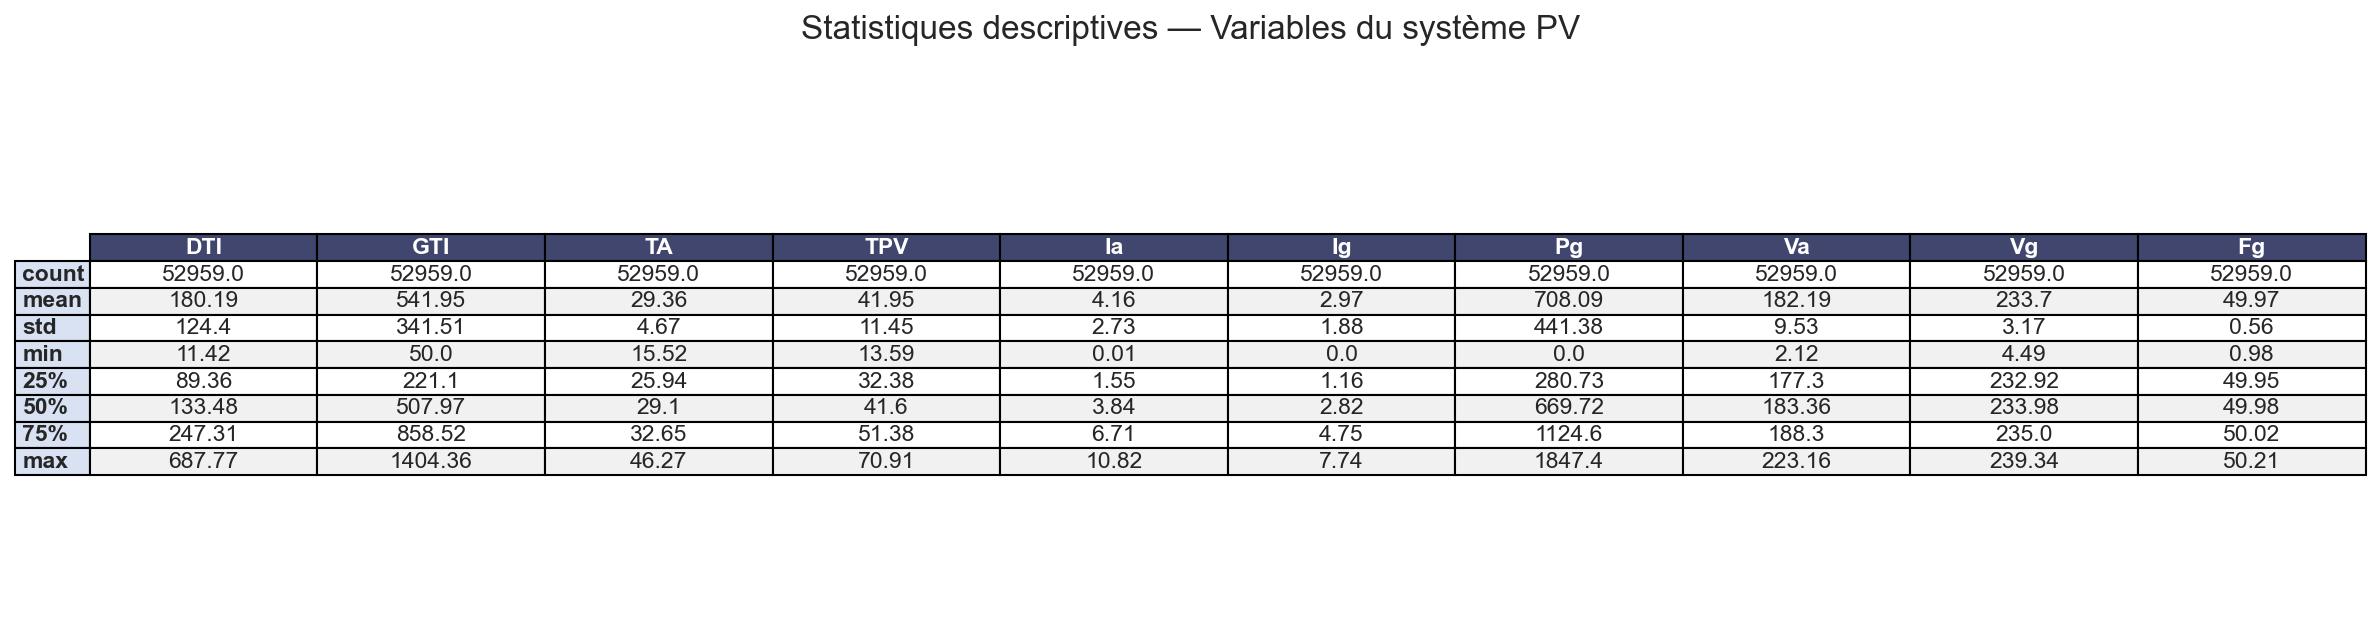

In [7]:
features = ["DTI", "GTI", "TA", "TPV", "Ia", "Ig", "Pg", "Va", "Vg", "Fg"]
desc = df[features].describe().round(2)

fig, ax = plt.subplots(figsize=(16, 4))
ax.axis("off")
tbl = ax.table(
    cellText=desc.values,
    rowLabels=desc.index,
    colLabels=desc.columns,
    cellLoc="center",
    loc="center",
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(11)
for (row, col), cell in tbl.get_celld().items():
    if row == 0:
        cell.set_facecolor("#40466e")
        cell.set_text_props(color="w", weight="bold")
    elif col == -1:
        cell.set_facecolor("#d9e2f3")
        cell.set_text_props(weight="bold")
    else:
        cell.set_facecolor("#f1f1f2" if row % 2 == 0 else "w")

fig.suptitle("Statistiques descriptives — Variables du système PV", fontsize=16, y=1.02)
plt.tight_layout()
save_fig("eda_01_stats_descriptives")
plt.show()

 ### 1.2 Variable cible — Répartition des pannes

  ✓ Sauvegardé : notebooks/figures/eda_02_repartition_pannes.png


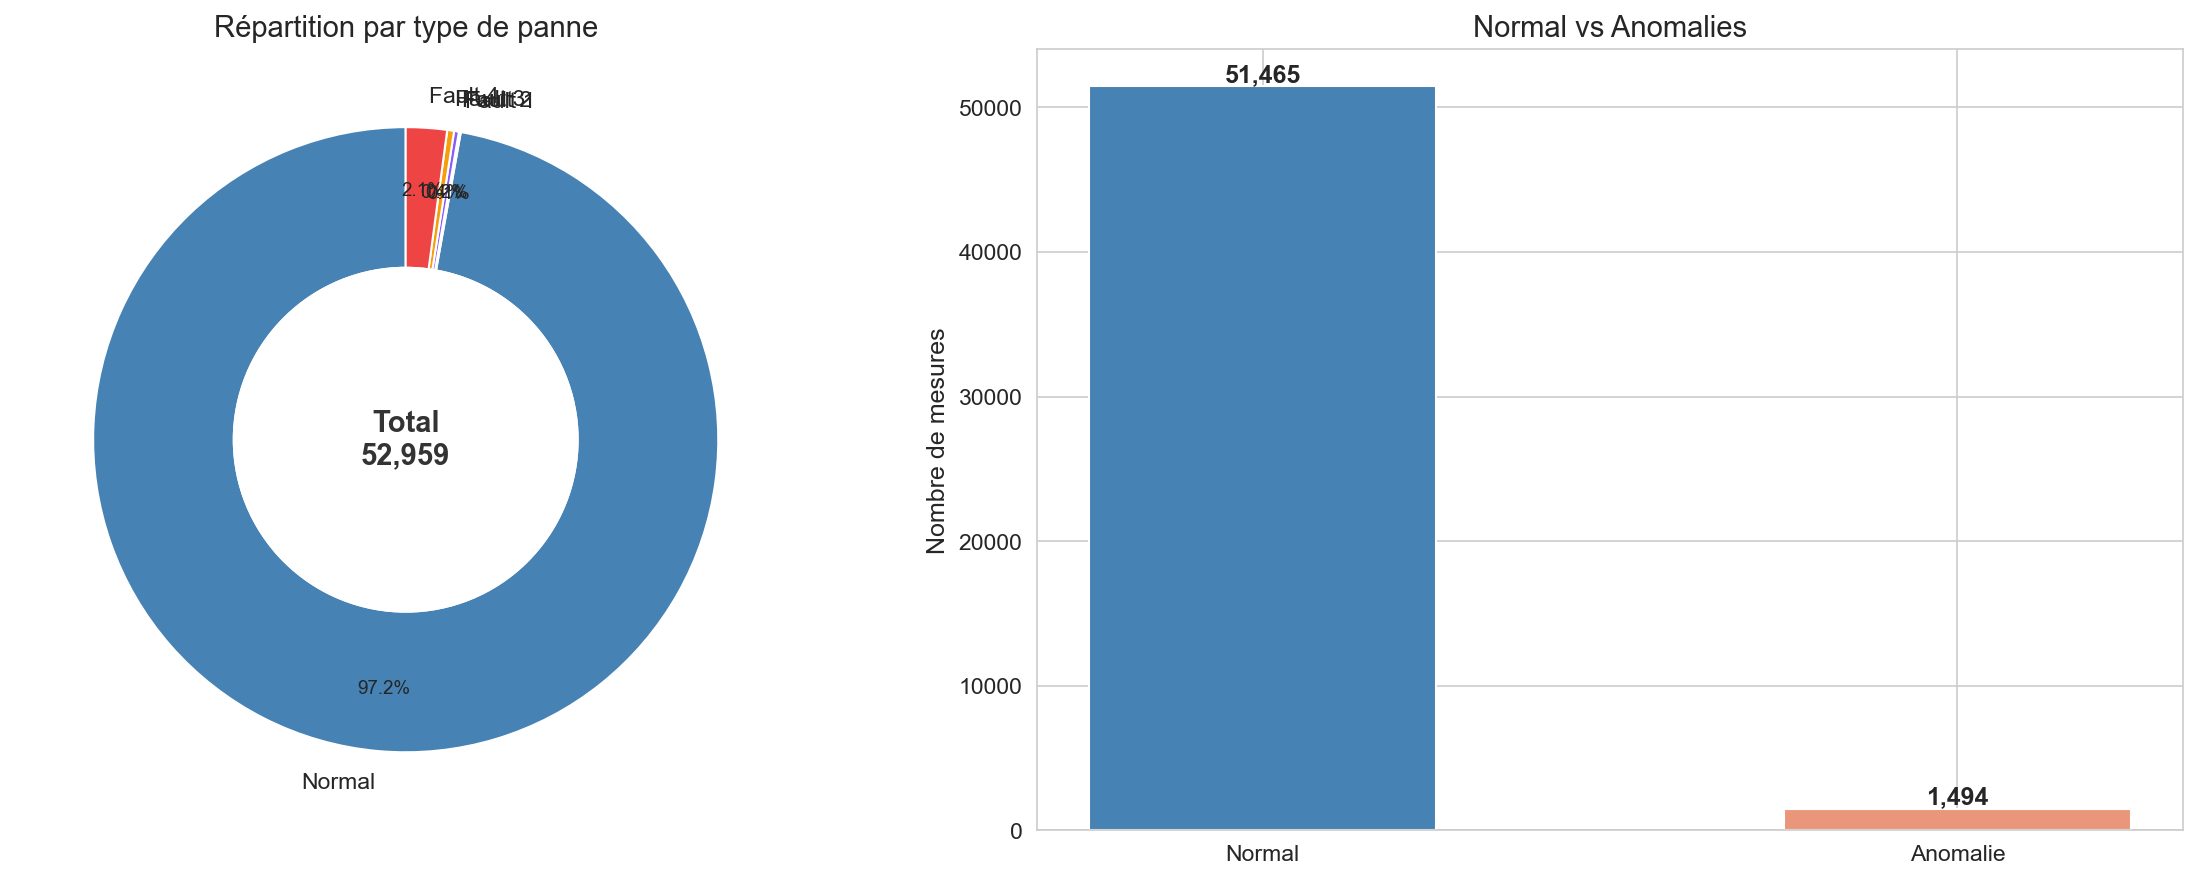

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Donut chart ---
counts = df["Fault"].value_counts().sort_index()
colors = [COLORS_FAULT.get(i, "#999999") for i in counts.index]
wedges, texts, autotexts = axes[0].pie(
    counts, labels=[f"Fault {i}" if i != 0 else "Normal" for i in counts.index],
    autopct="%1.1f%%", colors=colors, startangle=90,
    pctdistance=0.8, wedgeprops=dict(width=0.45, edgecolor="w"),
)
for t in autotexts:
    t.set_fontsize(9)
axes[0].set_title("Répartition par type de panne")
centre = plt.Circle((0, 0), 0.55, fc="white")
axes[0].add_artist(centre)
axes[0].text(0, 0, f"Total\n{len(df):,}", ha="center", va="center",
             fontsize=14, fontweight="bold", color="#333")

# --- Barplot binaire ---
binary_counts = df["fault_binary"].value_counts()
bars = axes[1].bar(binary_counts.index, binary_counts.values,
                   color=PALETTE_BINARY, edgecolor="w", width=0.5)
for bar in bars:
    axes[1].annotate(f"{bar.get_height():,}",
                     (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                     ha="center", va="bottom", fontsize=12, fontweight="bold")
axes[1].set_title("Normal vs Anomalies")
axes[1].set_ylabel("Nombre de mesures")

plt.tight_layout()
save_fig("eda_02_repartition_pannes")
plt.show()

# ============================================================================

 ---
 ## 2. Distributions des variables
 ---

  ✓ Sauvegardé : notebooks/figures/eda_03_kde_normal_vs_anomalie.png


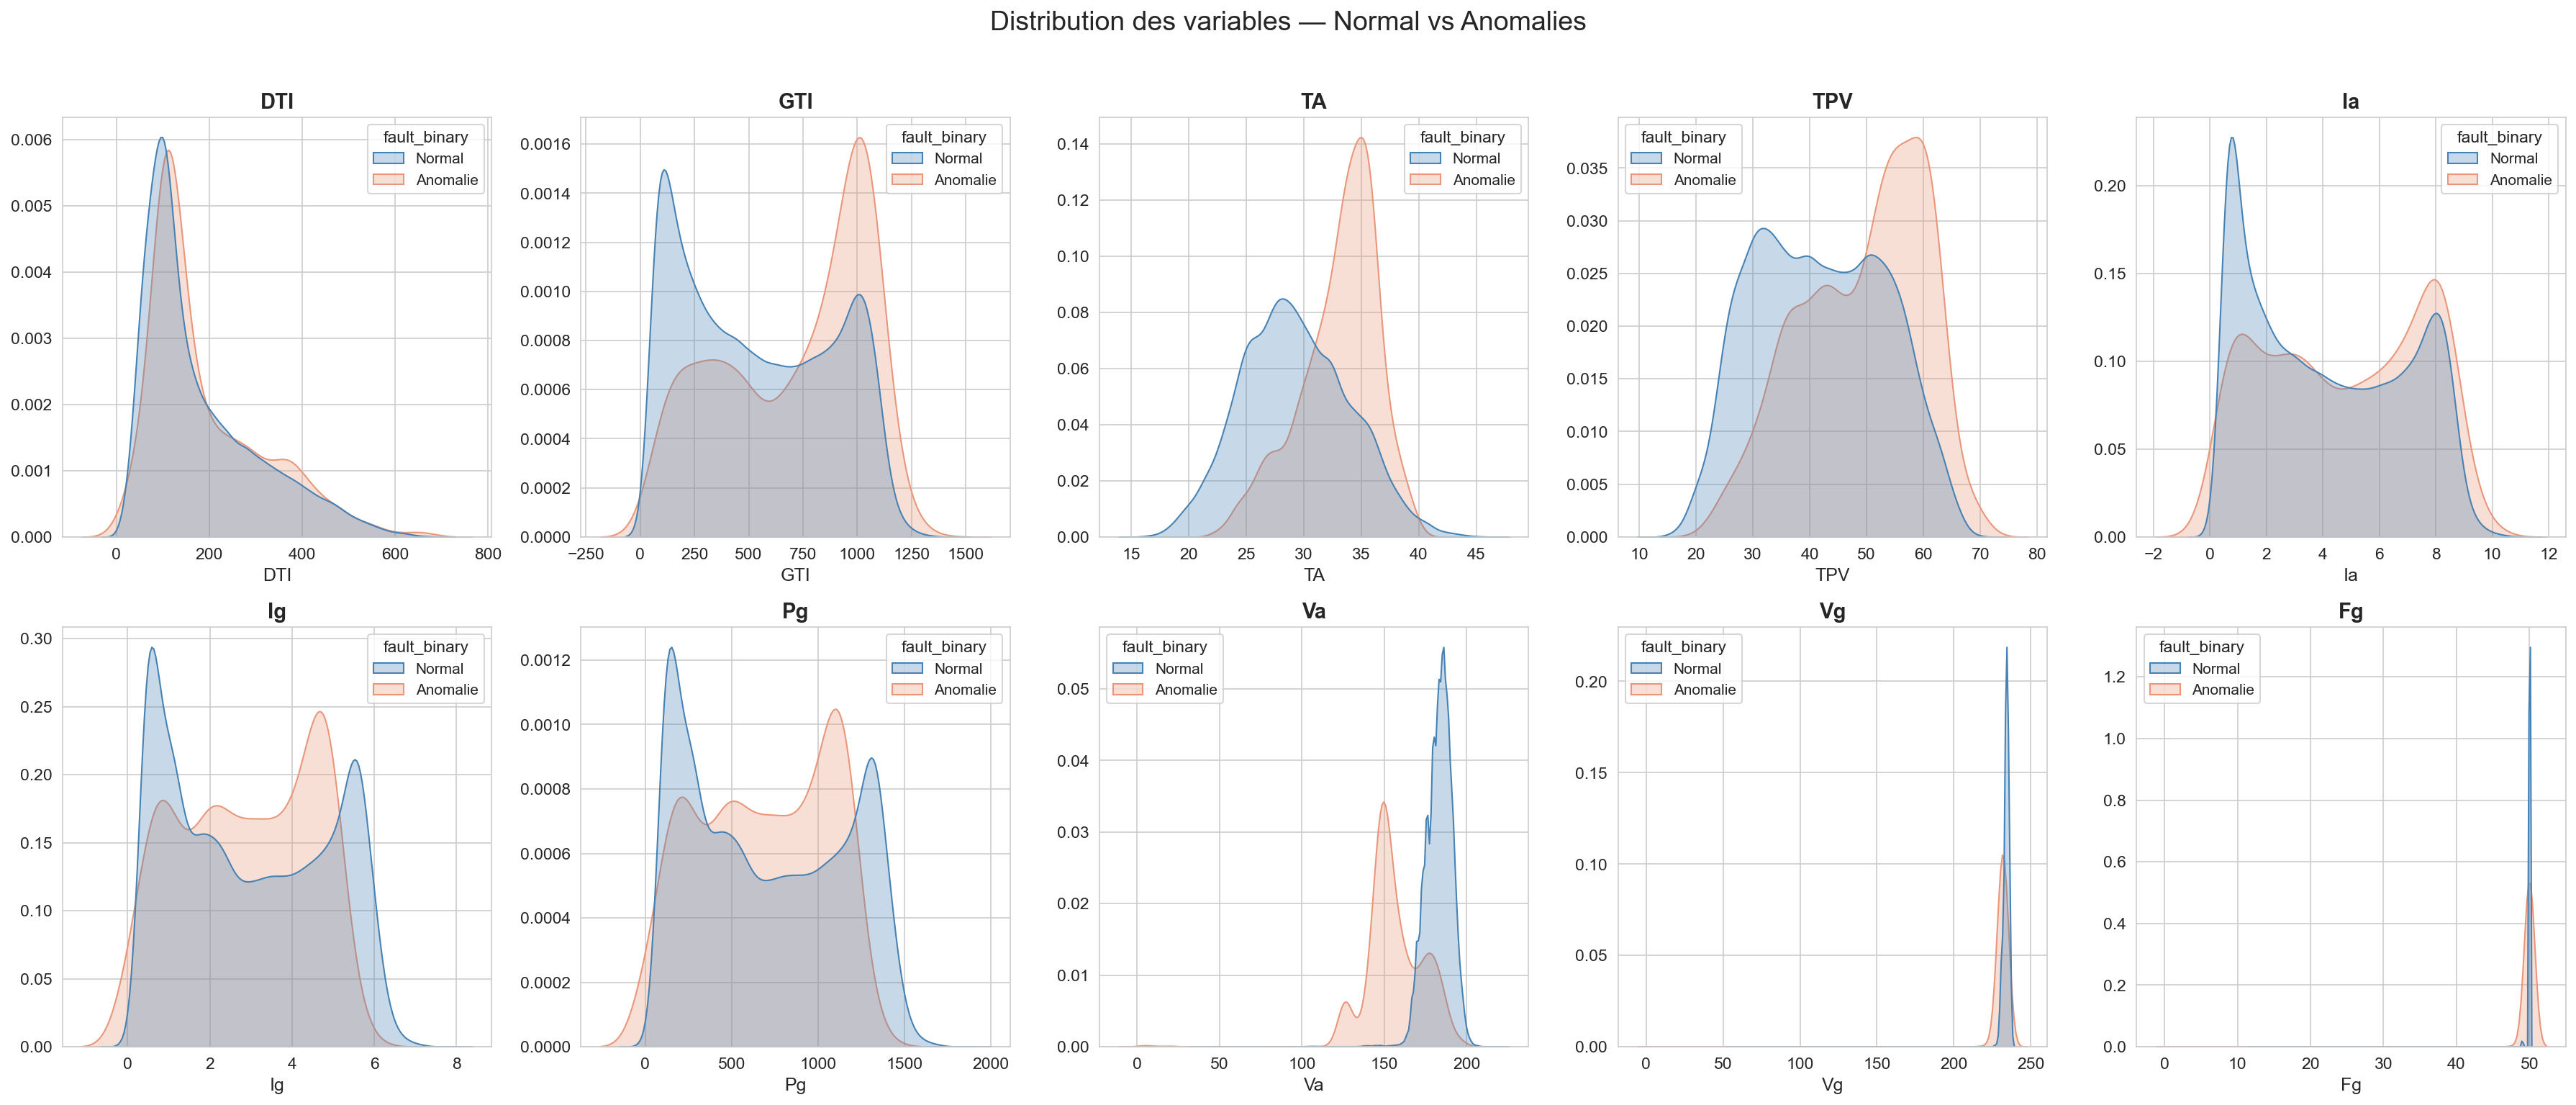

In [9]:
fig, axes = plt.subplots(2, 5, figsize=(24, 10))
axes = axes.flatten()

for i, col in enumerate(features):
    sns.kdeplot(data=df, x=col, hue="fault_binary",
                palette=PALETTE_BINARY, fill=True, alpha=0.3,
                ax=axes[i], common_norm=False)
    axes[i].set_title(col, fontweight="bold")
    axes[i].set_ylabel("")

fig.suptitle("Distribution des variables — Normal vs Anomalies", fontsize=18, y=1.02)
plt.tight_layout()
save_fig("eda_03_kde_normal_vs_anomalie")
plt.show()

 ### 2.2 KDE — Distribution par type de panne (détaillé)

  ✓ Sauvegardé : notebooks/figures/eda_04_kde_par_type_panne.png


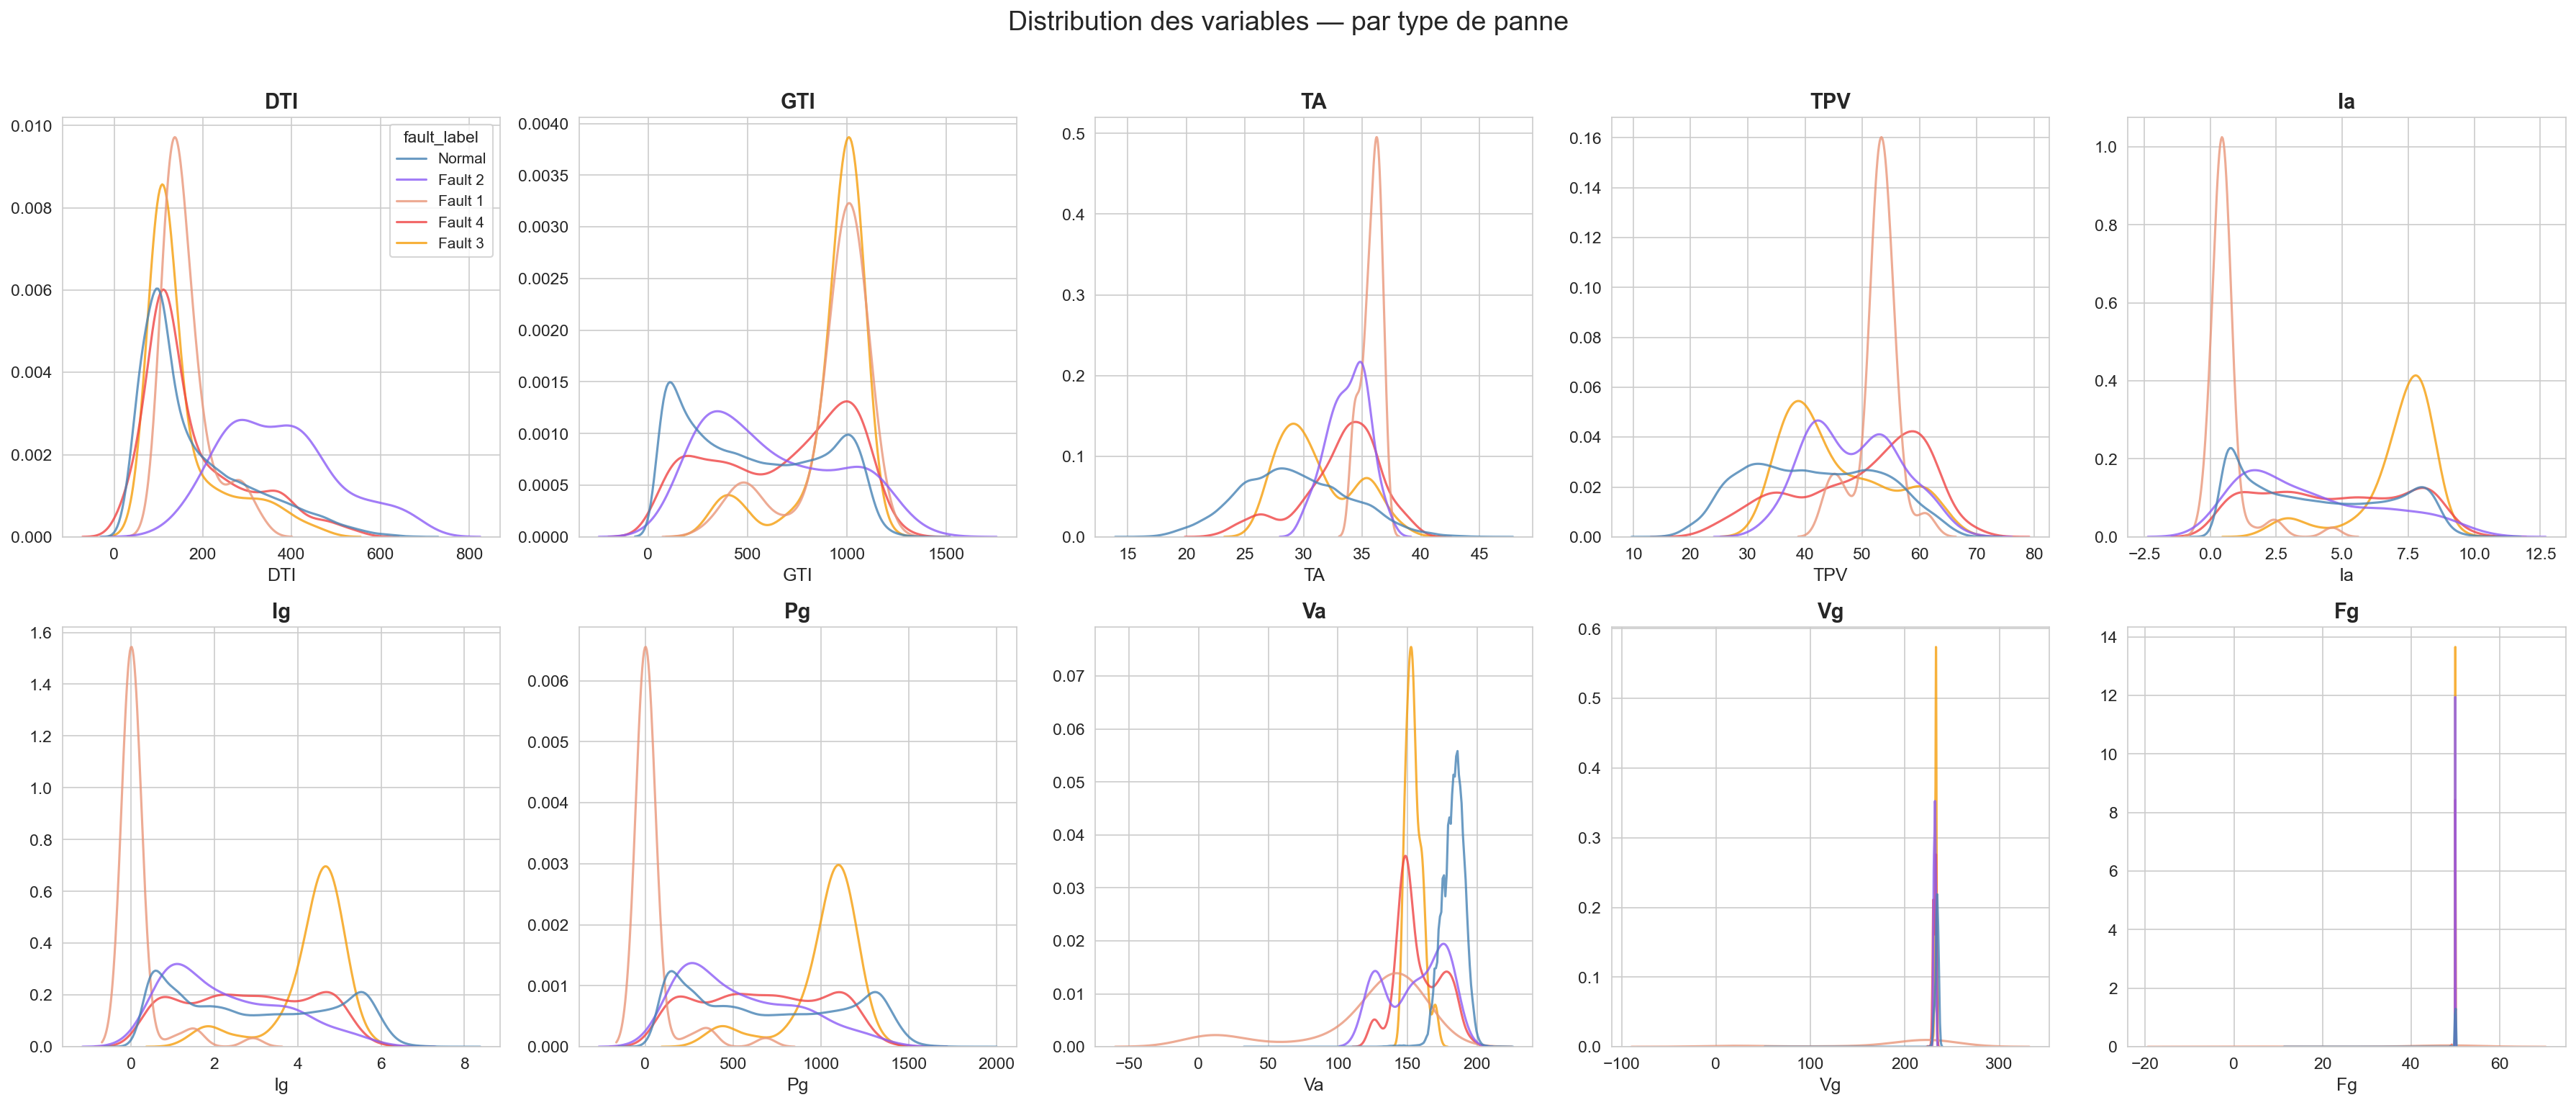

In [10]:
fig, axes = plt.subplots(2, 5, figsize=(24, 10))
axes = axes.flatten()

fault_palette = {k: v for k, v in zip(
    ["Normal", "Fault 1", "Fault 2", "Fault 3", "Fault 4", "Fault 5"],
    COLORS_FAULT.values()
)}

for i, col in enumerate(features):
    sns.kdeplot(data=df, x=col, hue="fault_label",
                palette=fault_palette, fill=False, alpha=0.8,
                ax=axes[i], common_norm=False, linewidth=1.5)
    axes[i].set_title(col, fontweight="bold")
    axes[i].set_ylabel("")
    if i > 0:
        axes[i].get_legend().remove()

fig.suptitle("Distribution des variables — par type de panne", fontsize=18, y=1.02)
plt.tight_layout()
save_fig("eda_04_kde_par_type_panne")
plt.show()

# ============================================================================

 ---
 ## 3. Relations entre variables
 ---

 ### 3.1 Matrice de corrélation

  ✓ Sauvegardé : notebooks/figures/eda_05_heatmap_correlation.png


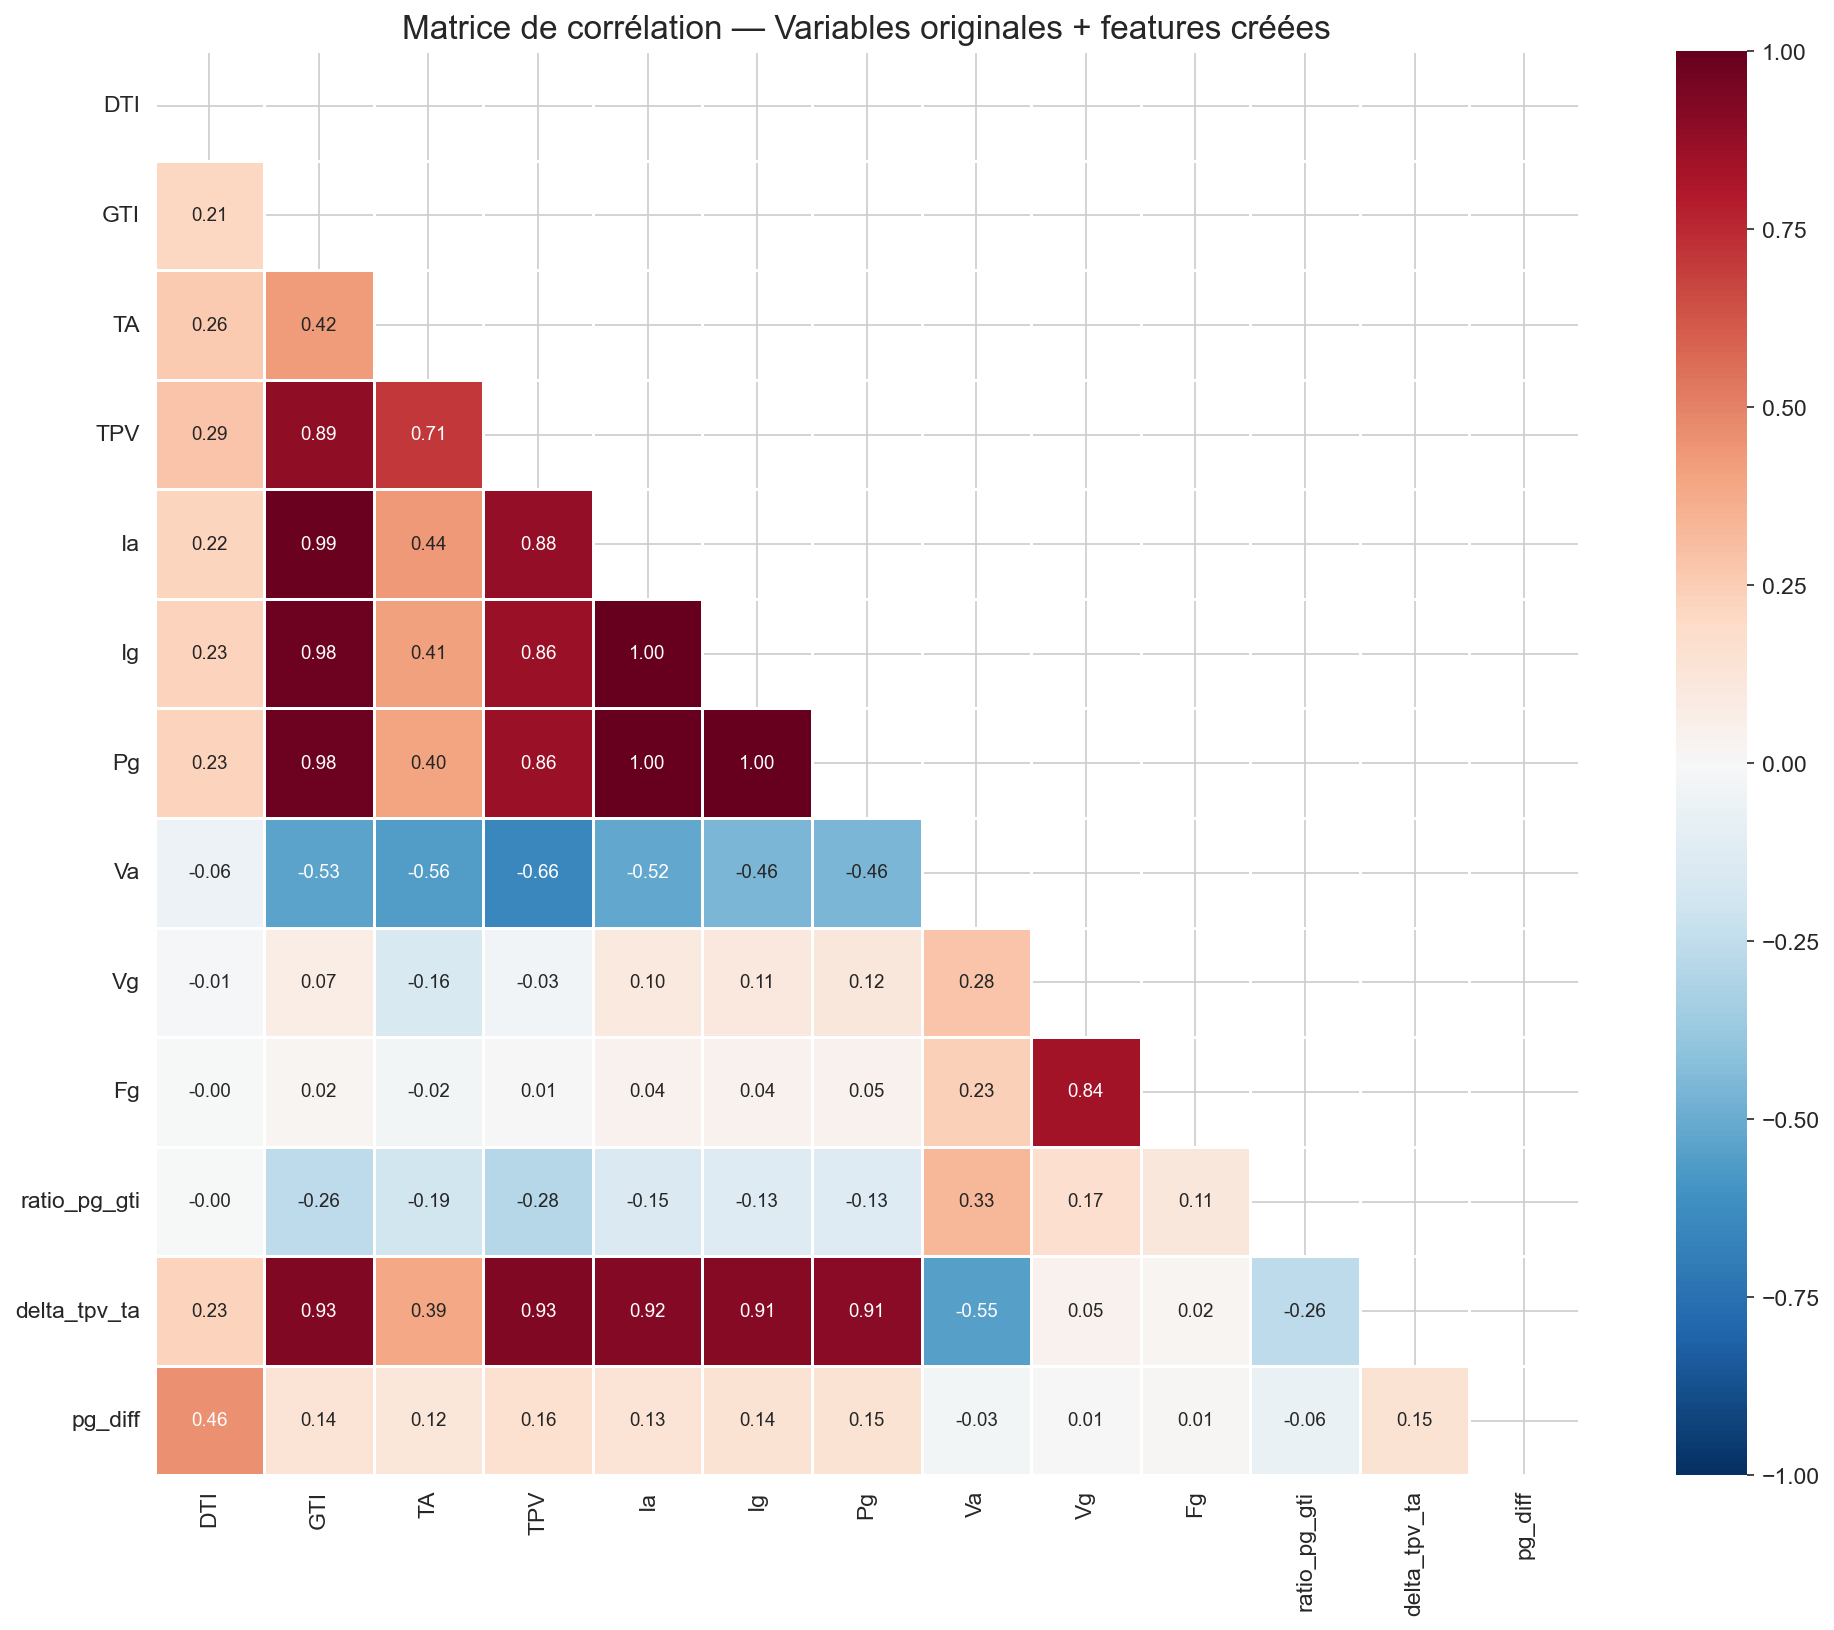

In [11]:
all_features = features + ["ratio_pg_gti", "delta_tpv_ta", "pg_diff"]
corr = df[all_features].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))
fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, vmin=-1, vmax=1, square=True,
            linewidths=0.5, ax=ax,
            annot_kws={"size": 9})
ax.set_title("Matrice de corrélation — Variables originales + features créées", fontsize=16)
plt.tight_layout()
save_fig("eda_05_heatmap_correlation")
plt.show()

 ### 3.2 Pairplot — Variables clés colorées par état

  ✓ Sauvegardé : notebooks/figures/eda_06_pairplot_cles.png


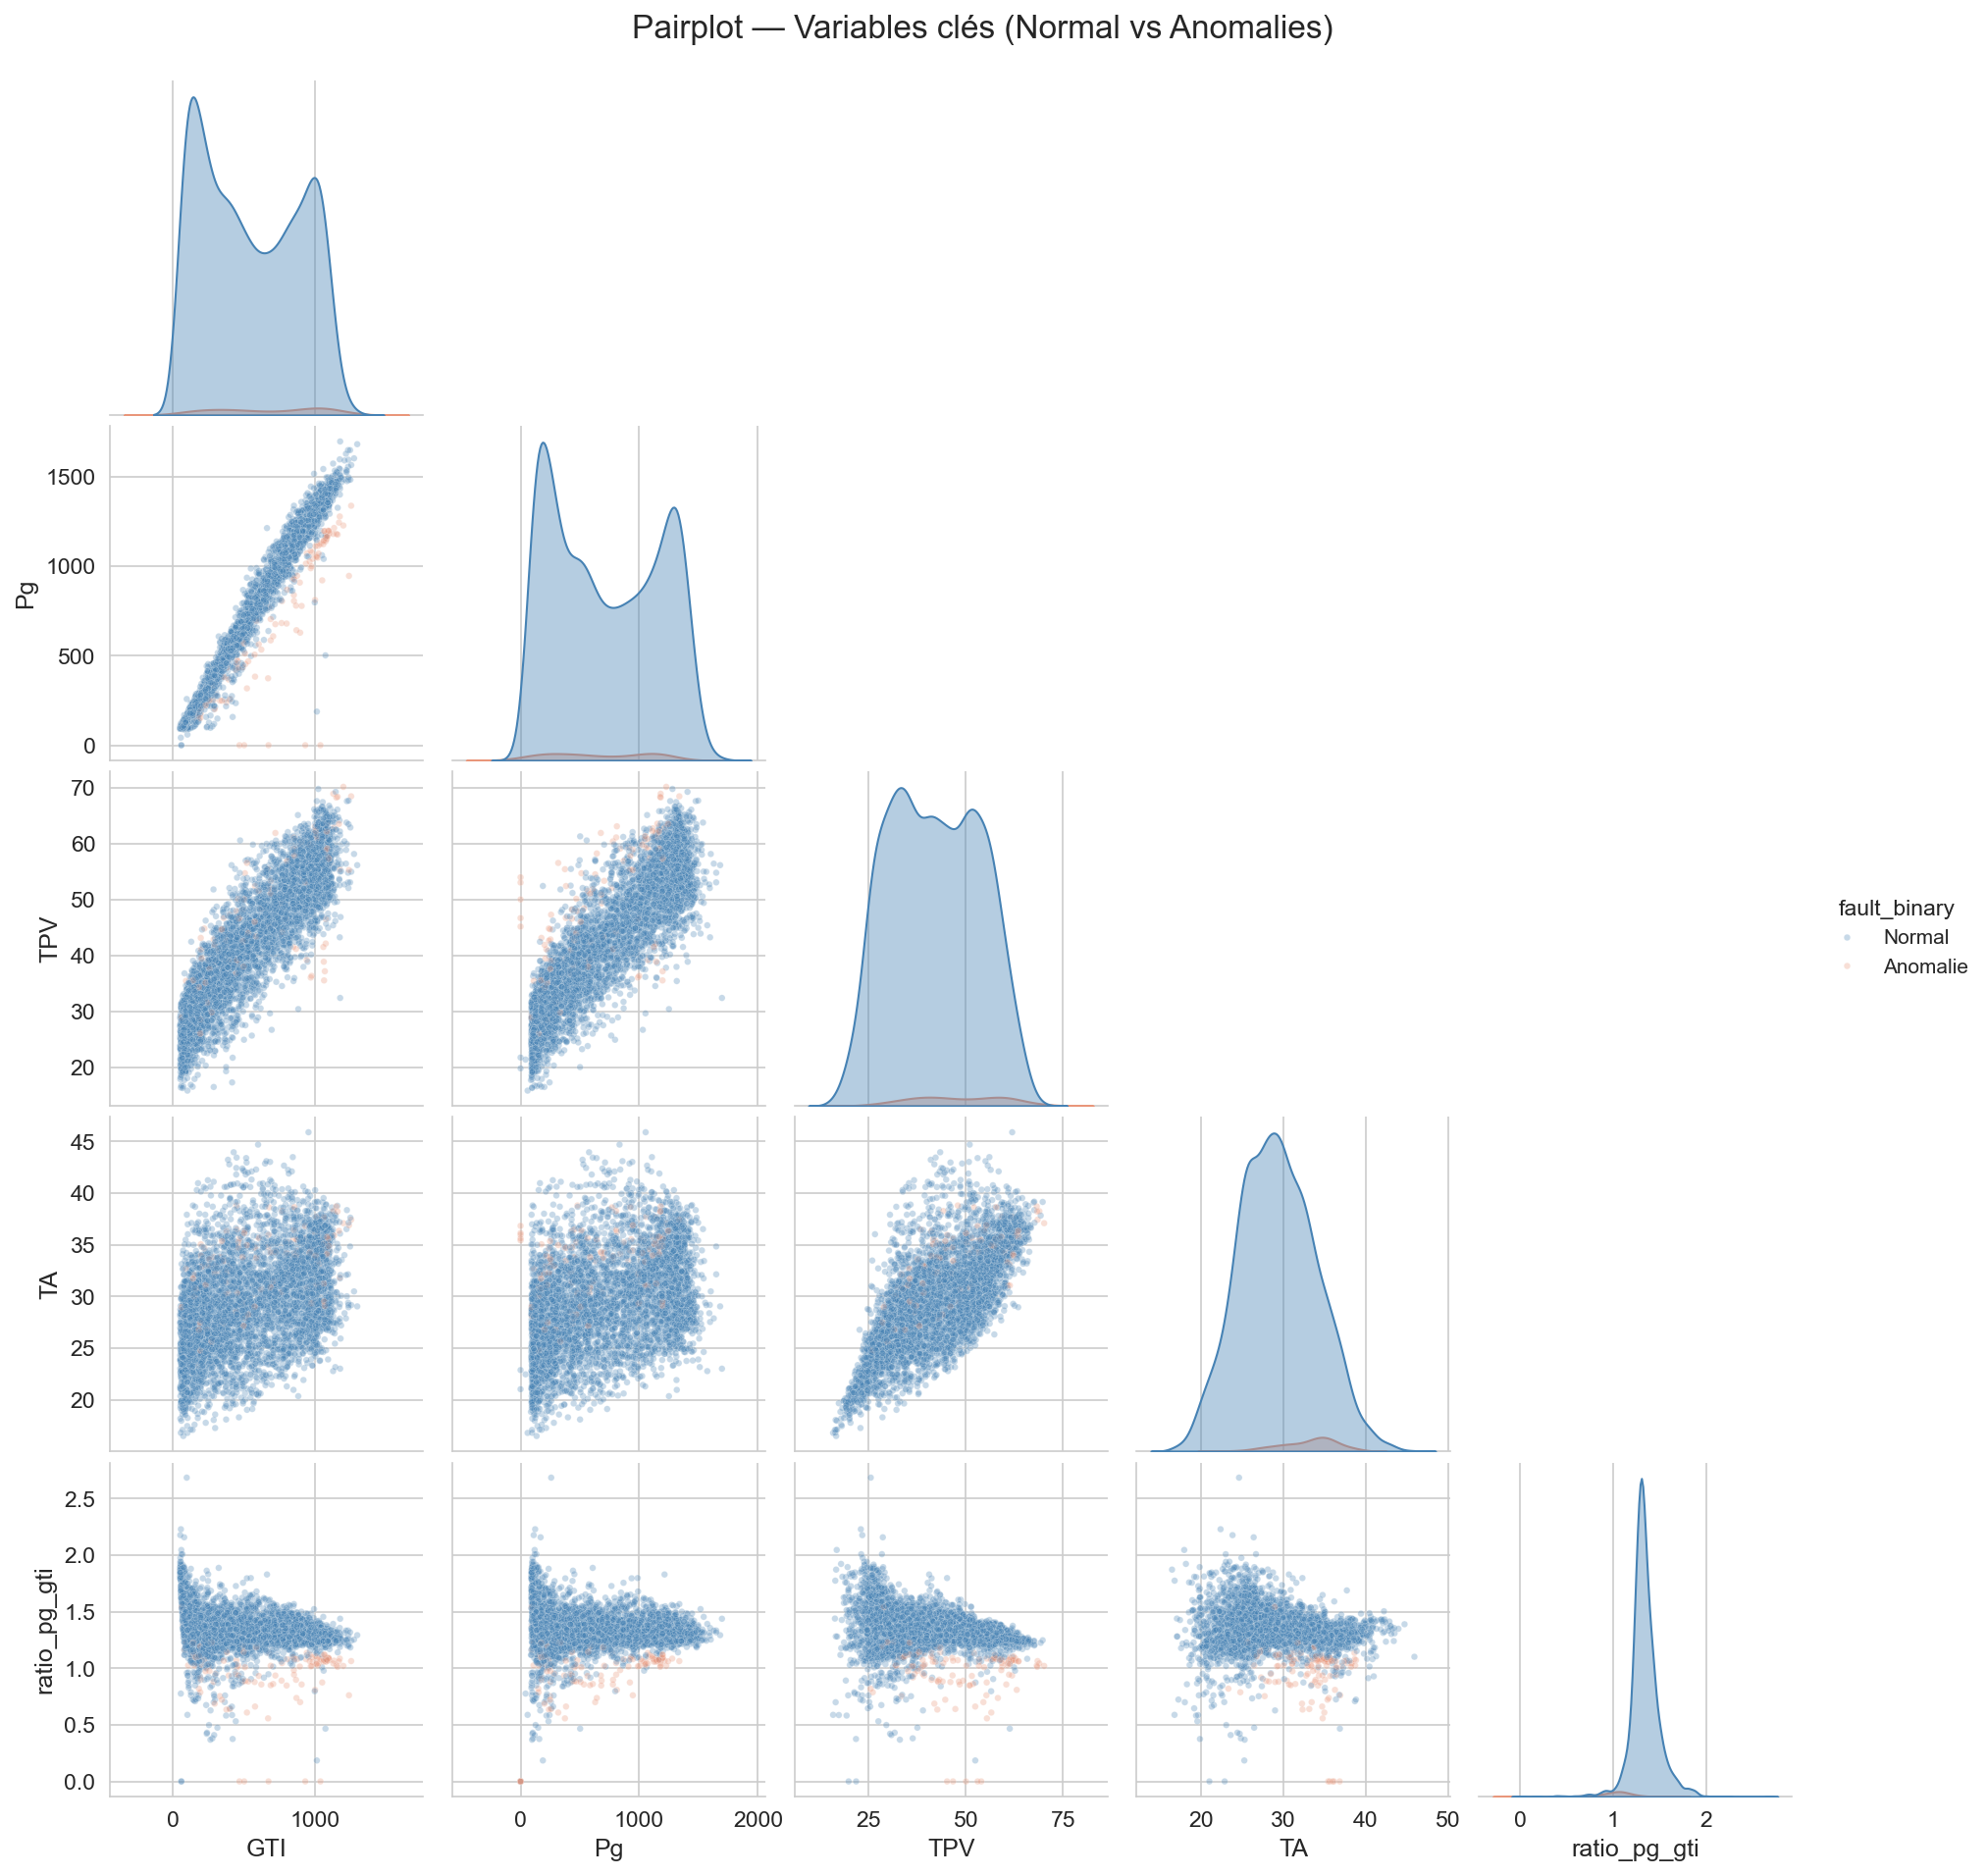

In [12]:
key_vars = ["GTI", "Pg", "TPV", "TA", "ratio_pg_gti", "fault_binary"]
sample = df[key_vars].sample(n=min(5000, len(df)), random_state=42)

g = sns.pairplot(sample, hue="fault_binary",
                 palette=PALETTE_BINARY,
                 plot_kws=dict(alpha=0.3, s=10),
                 diag_kws=dict(fill=True, alpha=0.4),
                 corner=True)
g.figure.suptitle("Pairplot — Variables clés (Normal vs Anomalies)", y=1.02, fontsize=16)
save_fig("eda_06_pairplot_cles")
plt.show()

# ============================================================================

 ---
 ## 4. Analyse des interactions clés
 ---

 ### 4.1 GTI vs Pg — La relation fondamentale
 L'irradiance solaire (GTI) et la puissance produite (Pg) doivent
 suivre une relation linéaire. Les écarts révèlent les anomalies.

  ✓ Sauvegardé : notebooks/figures/eda_07_gti_vs_pg.png


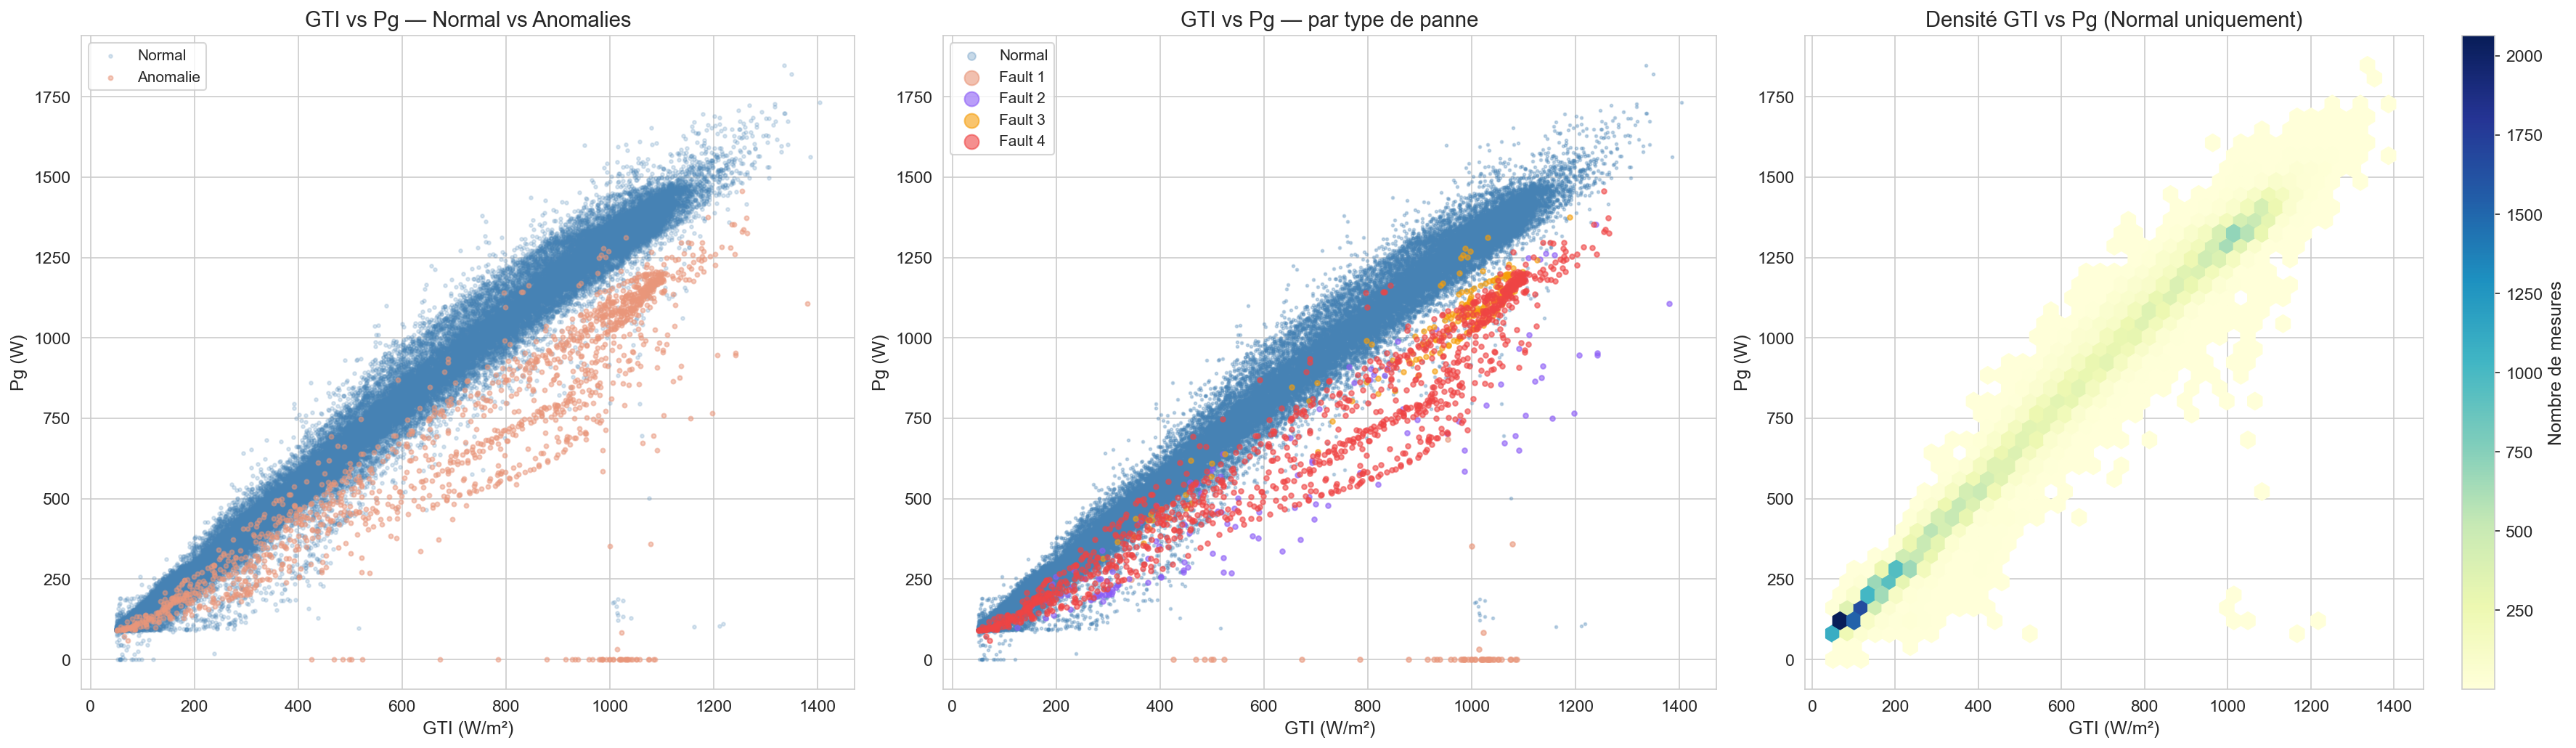

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(24, 7))

# Scatter global
axes[0].scatter(df.loc[df["Fault"] == 0, "GTI"],
                df.loc[df["Fault"] == 0, "Pg"],
                c=COLORS_FAULT[0], alpha=0.2, s=5, label="Normal")
axes[0].scatter(df.loc[df["Fault"] != 0, "GTI"],
                df.loc[df["Fault"] != 0, "Pg"],
                c="#E9967A", alpha=0.5, s=8, label="Anomalie")
axes[0].set_xlabel("GTI (W/m²)")
axes[0].set_ylabel("Pg (W)")
axes[0].set_title("GTI vs Pg — Normal vs Anomalies")
axes[0].legend()

# Scatter par type de panne
for fault_id in sorted(df["Fault"].unique()):
    subset = df[df["Fault"] == fault_id]
    axes[1].scatter(subset["GTI"], subset["Pg"],
                    c=COLORS_FAULT.get(fault_id, "#999"),
                    alpha=0.3 if fault_id == 0 else 0.6,
                    s=3 if fault_id == 0 else 10,
                    label=f"Fault {fault_id}" if fault_id != 0 else "Normal")
axes[1].set_xlabel("GTI (W/m²)")
axes[1].set_ylabel("Pg (W)")
axes[1].set_title("GTI vs Pg — par type de panne")
axes[1].legend(markerscale=3)

# Hexbin densité (normal seulement)
normal = df[df["Fault"] == 0]
hb = axes[2].hexbin(normal["GTI"], normal["Pg"],
                     gridsize=40, cmap="YlGnBu", mincnt=1)
axes[2].set_xlabel("GTI (W/m²)")
axes[2].set_ylabel("Pg (W)")
axes[2].set_title("Densité GTI vs Pg (Normal uniquement)")
plt.colorbar(hb, ax=axes[2], label="Nombre de mesures")

plt.tight_layout()
save_fig("eda_07_gti_vs_pg")
plt.show()

 ### 4.2 Ratio Pg/GTI — L'indicateur de rendement

C:\Users\PC\AppData\Local\Temp\ipykernel_17056\3319525691.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="fault_label", y="ratio_pg_gti",
C:\Users\PC\AppData\Local\Temp\ipykernel_17056\3319525691.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=sample_strip, x="fault_label", y="ratio_pg_gti",


  ✓ Sauvegardé : notebooks/figures/eda_08_ratio_pg_gti.png


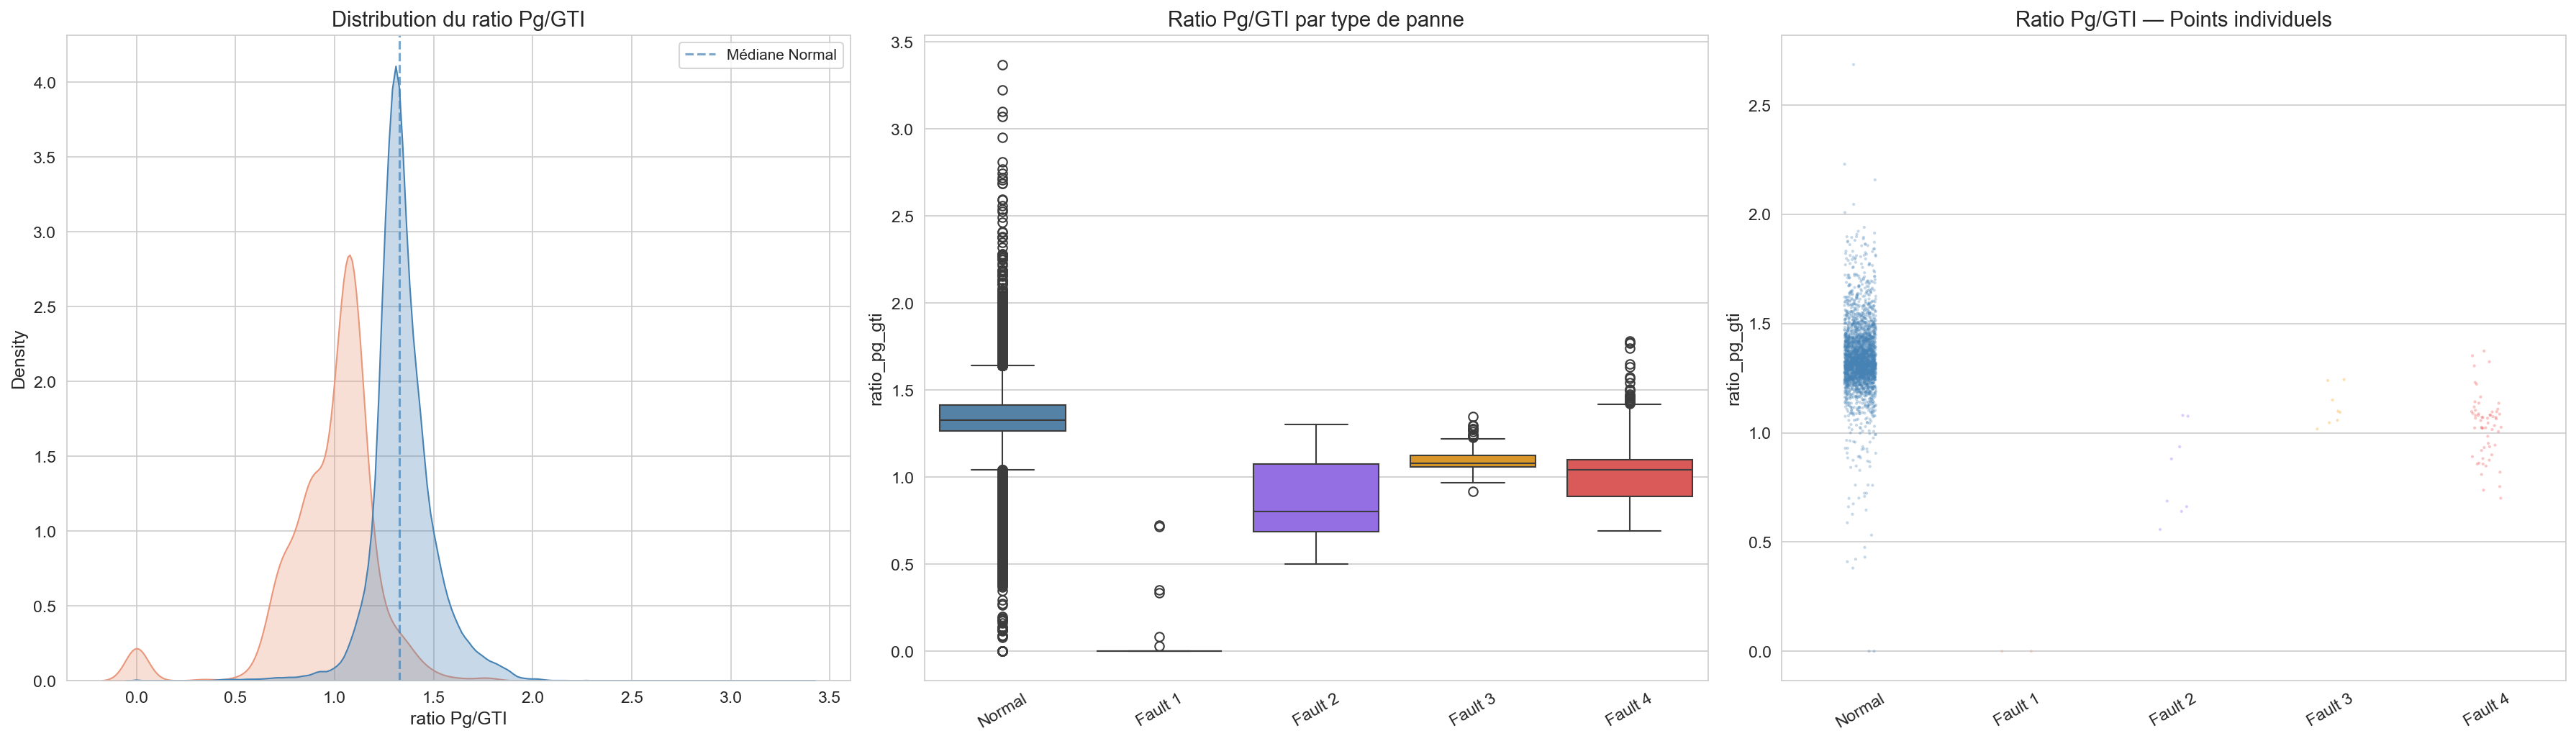

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(24, 7))

# KDE du ratio par état
sns.kdeplot(data=df, x="ratio_pg_gti", hue="fault_binary",
            palette=PALETTE_BINARY, fill=True, alpha=0.3,
            ax=axes[0], common_norm=False)
axes[0].set_title("Distribution du ratio Pg/GTI")
axes[0].set_xlabel("ratio Pg/GTI")
axes[0].axvline(df.loc[df["Fault"] == 0, "ratio_pg_gti"].median(),
                color=COLORS_FAULT[0], linestyle="--", alpha=0.7, label="Médiane Normal")
axes[0].legend()

# Boxplot du ratio par type de panne
fault_order = ["Normal", "Fault 1", "Fault 2", "Fault 3", "Fault 4", "Fault 5"]
existing = [f for f in fault_order if f in df["fault_label"].unique()]
sns.boxplot(data=df, x="fault_label", y="ratio_pg_gti",
            palette=fault_palette, order=existing, ax=axes[1])
axes[1].set_title("Ratio Pg/GTI par type de panne")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=30)

# Stripplot échantillonné
sample_strip = df.sample(n=min(3000, len(df)), random_state=42)
sns.stripplot(data=sample_strip, x="fault_label", y="ratio_pg_gti",
              palette=fault_palette, order=existing,
              alpha=0.3, size=2, jitter=True, ax=axes[2])
axes[2].set_title("Ratio Pg/GTI — Points individuels")
axes[2].set_xlabel("")
axes[2].tick_params(axis="x", rotation=30)

plt.tight_layout()
save_fig("eda_08_ratio_pg_gti")
plt.show()

 ### 4.3 Température — TPV vs TA (échauffement du panneau)

C:\Users\PC\AppData\Local\Temp\ipykernel_17056\3240891095.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x="fault_label", y="delta_tpv_ta",


  ✓ Sauvegardé : notebooks/figures/eda_09_temperature.png


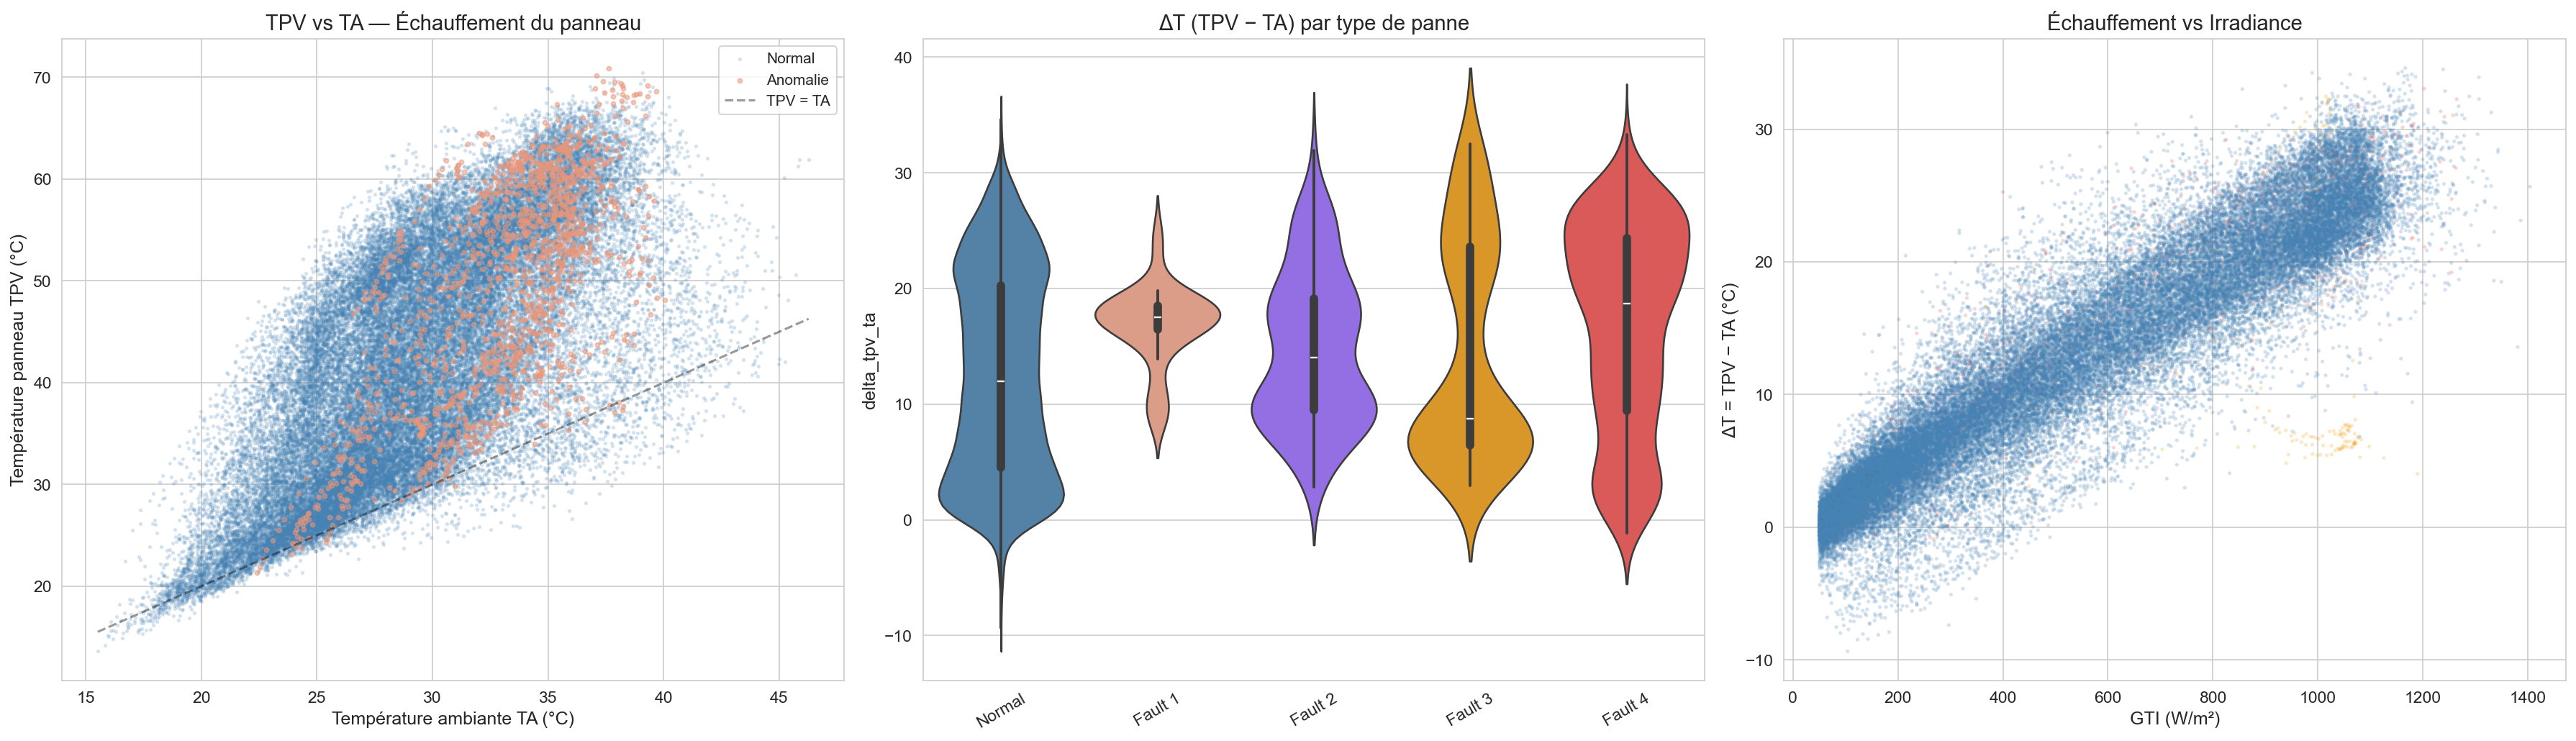

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(24, 7))

# Scatter TPV vs TA
axes[0].scatter(df.loc[df["Fault"] == 0, "TA"],
                df.loc[df["Fault"] == 0, "TPV"],
                c=COLORS_FAULT[0], alpha=0.15, s=3, label="Normal")
axes[0].scatter(df.loc[df["Fault"] != 0, "TA"],
                df.loc[df["Fault"] != 0, "TPV"],
                c="#E9967A", alpha=0.5, s=8, label="Anomalie")
axes[0].plot([df["TA"].min(), df["TA"].max()],
             [df["TA"].min(), df["TA"].max()],
             "k--", alpha=0.4, label="TPV = TA")
axes[0].set_xlabel("Température ambiante TA (°C)")
axes[0].set_ylabel("Température panneau TPV (°C)")
axes[0].set_title("TPV vs TA — Échauffement du panneau")
axes[0].legend()

# Delta TPV-TA par panne
sns.violinplot(data=df, x="fault_label", y="delta_tpv_ta",
               palette=fault_palette, order=existing,
               inner="box", ax=axes[1])
axes[1].set_title("ΔT (TPV − TA) par type de panne")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=30)

# Delta vs GTI (l'échauffement dépend de l'irradiance)
scatter = axes[2].scatter(df["GTI"], df["delta_tpv_ta"],
                          c=df["Fault"].map(COLORS_FAULT),
                          alpha=0.15, s=3)
axes[2].set_xlabel("GTI (W/m²)")
axes[2].set_ylabel("ΔT = TPV − TA (°C)")
axes[2].set_title("Échauffement vs Irradiance")

plt.tight_layout()
save_fig("eda_09_temperature")
plt.show()

 ### 4.4 Courant et Tension — Ia, Ig, Va, Vg

C:\Users\PC\AppData\Local\Temp\ipykernel_17056\3746087051.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(data=df, x="fault_label", y="Ia",
C:\Users\PC\AppData\Local\Temp\ipykernel_17056\3746087051.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(data=df, x="fault_label", y="Va",


  ✓ Sauvegardé : notebooks/figures/eda_10_courant_tension.png


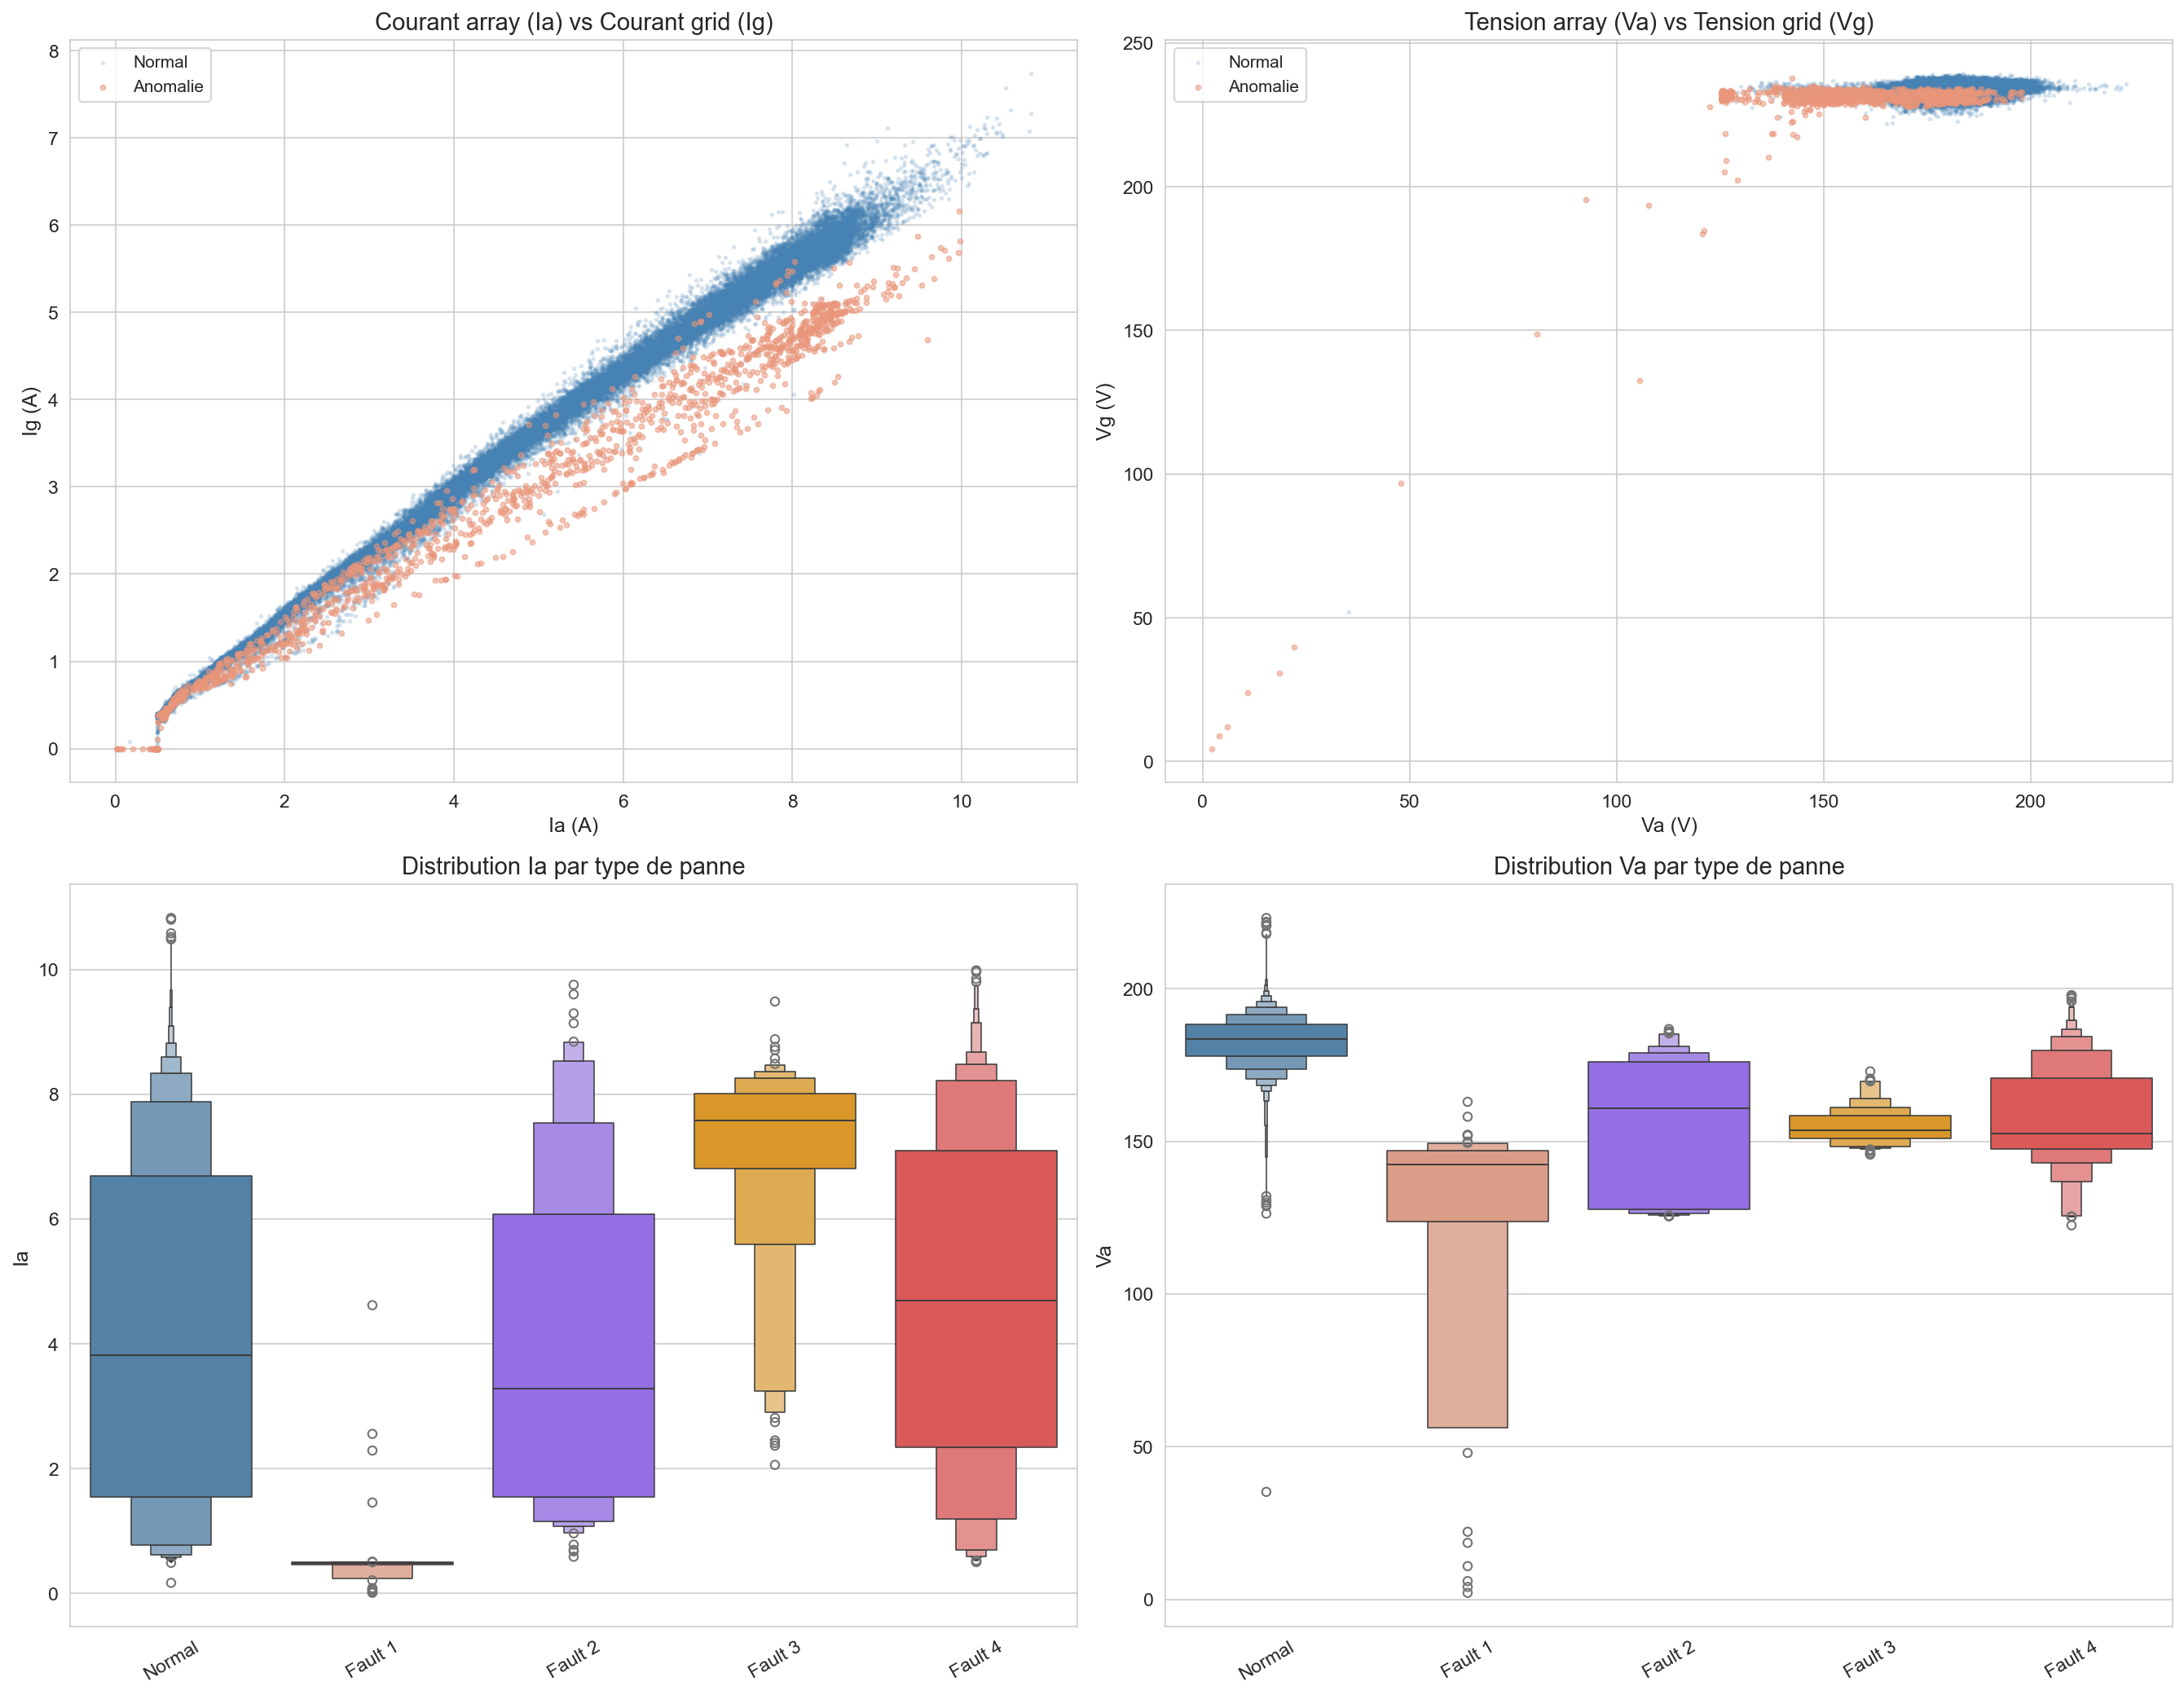

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# Ia vs Ig
axes[0, 0].scatter(df.loc[df["Fault"] == 0, "Ia"],
                   df.loc[df["Fault"] == 0, "Ig"],
                   c=COLORS_FAULT[0], alpha=0.15, s=3, label="Normal")
axes[0, 0].scatter(df.loc[df["Fault"] != 0, "Ia"],
                   df.loc[df["Fault"] != 0, "Ig"],
                   c="#E9967A", alpha=0.5, s=8, label="Anomalie")
axes[0, 0].set_xlabel("Ia (A)")
axes[0, 0].set_ylabel("Ig (A)")
axes[0, 0].set_title("Courant array (Ia) vs Courant grid (Ig)")
axes[0, 0].legend()

# Va vs Vg
axes[0, 1].scatter(df.loc[df["Fault"] == 0, "Va"],
                   df.loc[df["Fault"] == 0, "Vg"],
                   c=COLORS_FAULT[0], alpha=0.15, s=3, label="Normal")
axes[0, 1].scatter(df.loc[df["Fault"] != 0, "Va"],
                   df.loc[df["Fault"] != 0, "Vg"],
                   c="#E9967A", alpha=0.5, s=8, label="Anomalie")
axes[0, 1].set_xlabel("Va (V)")
axes[0, 1].set_ylabel("Vg (V)")
axes[0, 1].set_title("Tension array (Va) vs Tension grid (Vg)")
axes[0, 1].legend()

# Boxenplot Ia par panne
sns.boxenplot(data=df, x="fault_label", y="Ia",
              palette=fault_palette, order=existing, ax=axes[1, 0])
axes[1, 0].set_title("Distribution Ia par type de panne")
axes[1, 0].set_xlabel("")
axes[1, 0].tick_params(axis="x", rotation=30)

# Boxenplot Va par panne
sns.boxenplot(data=df, x="fault_label", y="Va",
              palette=fault_palette, order=existing, ax=axes[1, 1])
axes[1, 1].set_title("Distribution Va par type de panne")
axes[1, 1].set_xlabel("")
axes[1, 1].tick_params(axis="x", rotation=30)

plt.tight_layout()
save_fig("eda_10_courant_tension")
plt.show()

# ============================================================================

 ---
 ## 5. Analyse temporelle
 ---

 ### 5.1 Répartition des anomalies par mois

C:\Users\PC\AppData\Local\Temp\ipykernel_17056\3883400298.py:1: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  monthly = df.groupby([df.index.to_period("M"), "fault_binary"]).size().unstack(fill_value=0)


  ✓ Sauvegardé : notebooks/figures/eda_11_anomalies_par_mois.png


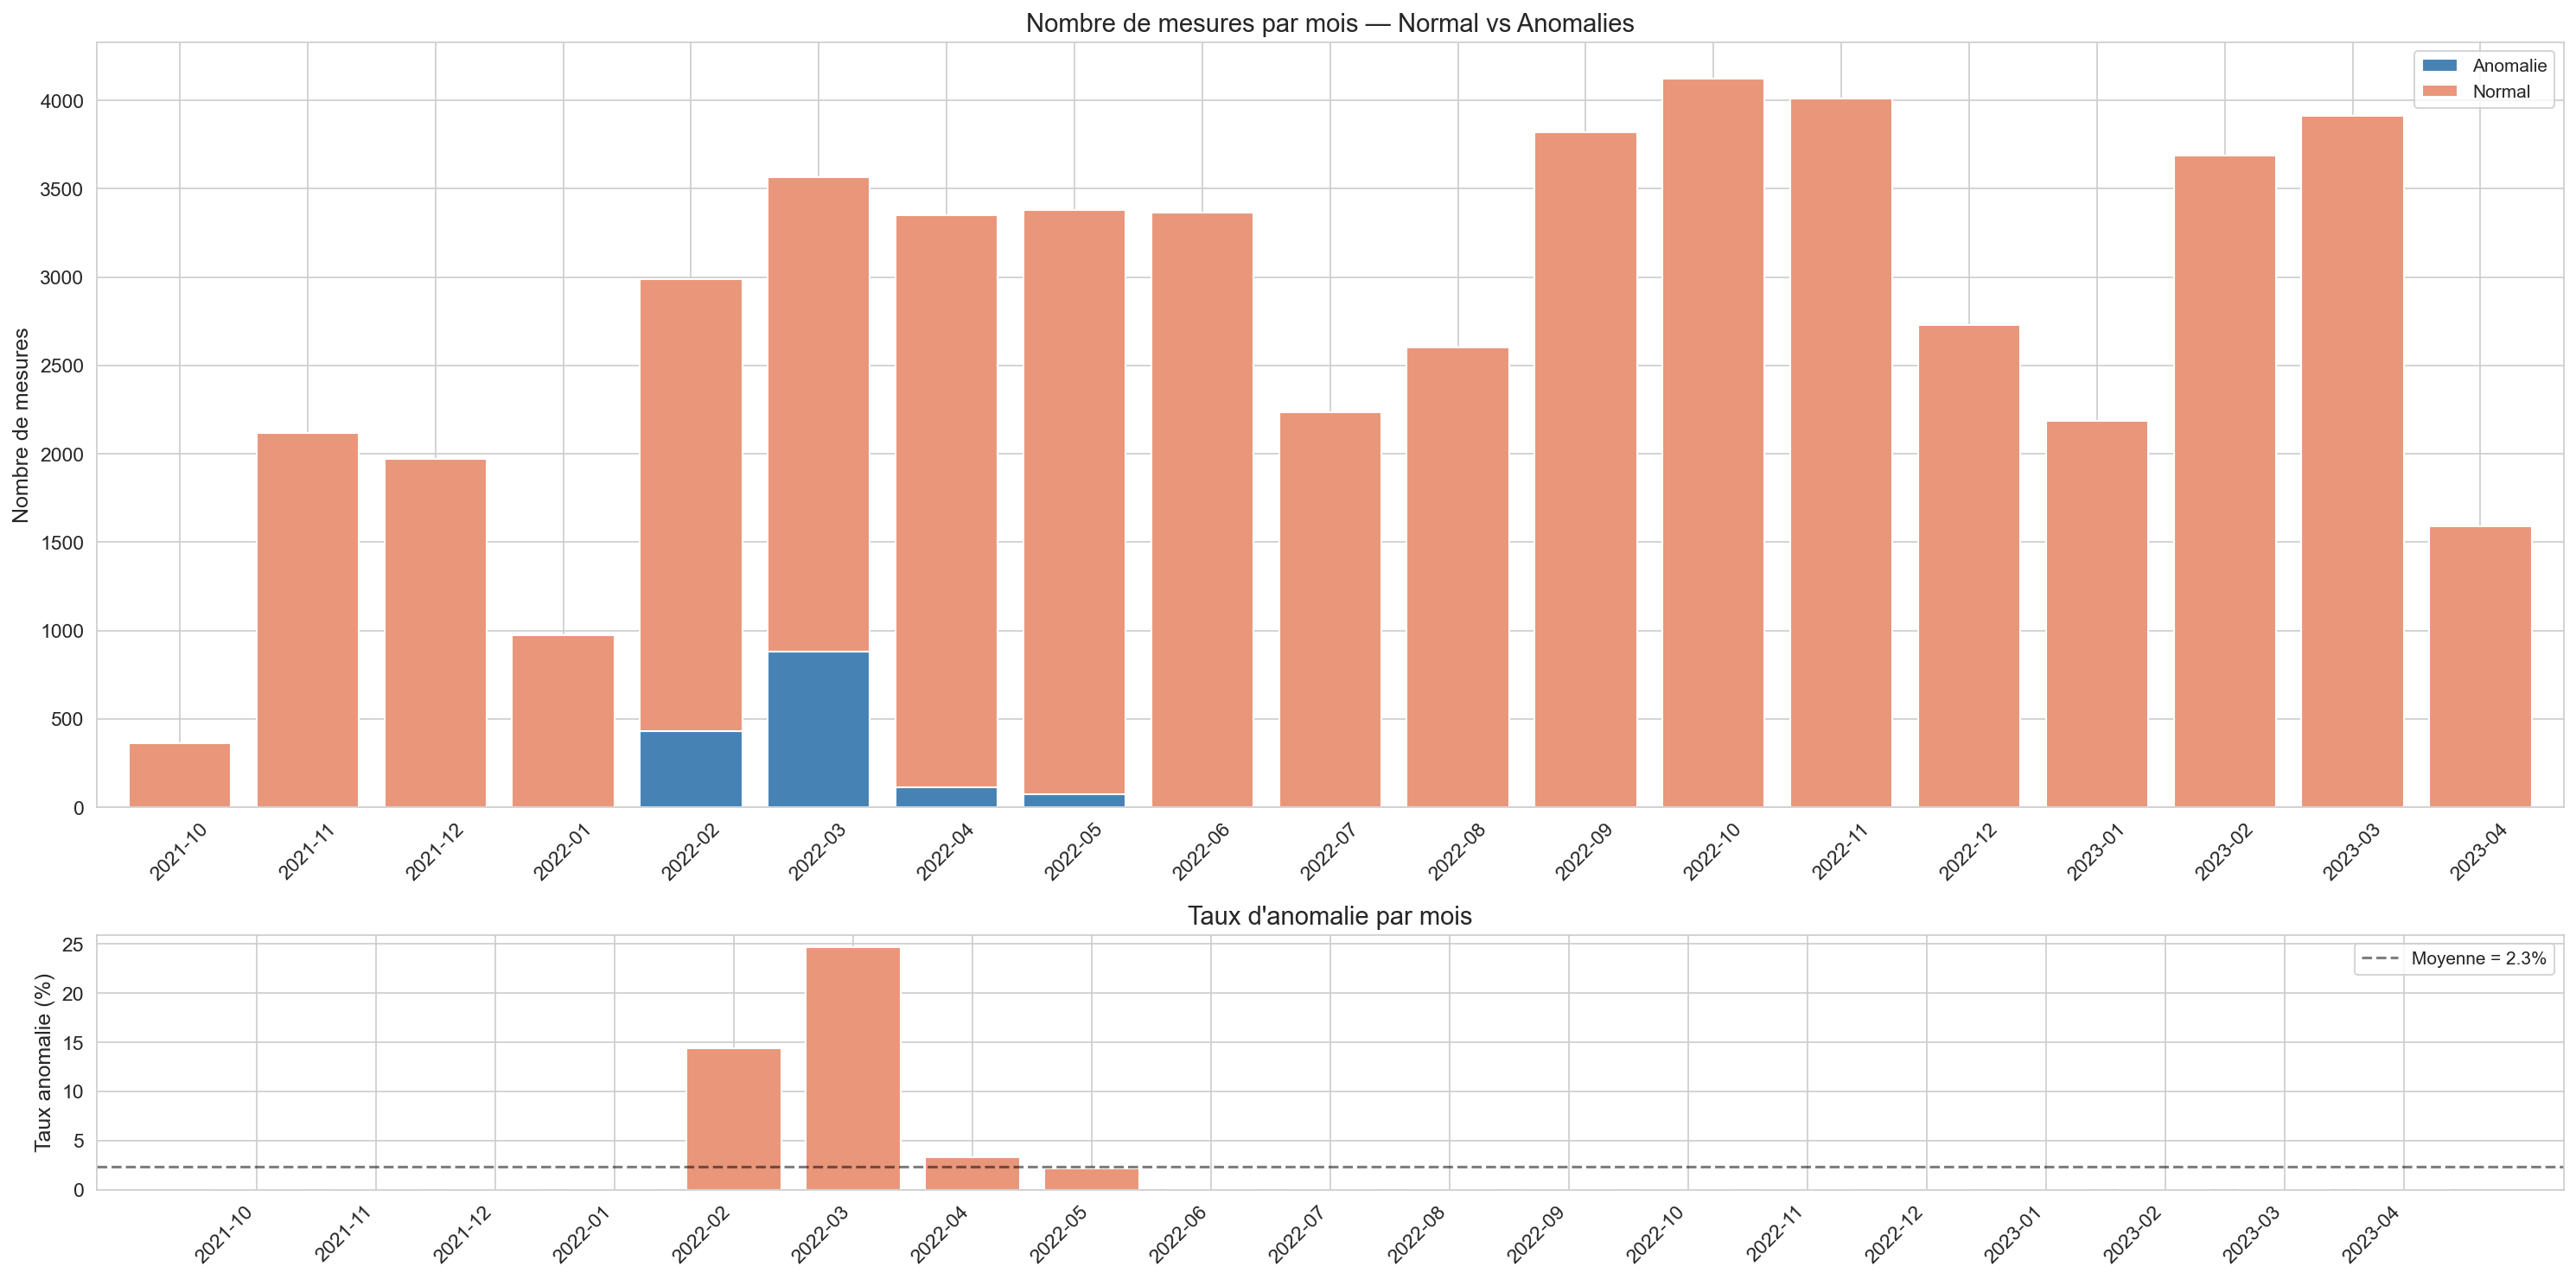

In [17]:
monthly = df.groupby([df.index.to_period("M"), "fault_binary"]).size().unstack(fill_value=0)
monthly.index = monthly.index.astype(str)

fig, axes = plt.subplots(2, 1, figsize=(20, 10), gridspec_kw={"height_ratios": [3, 1]})

monthly.plot(kind="bar", stacked=True, color=PALETTE_BINARY, ax=axes[0],
             width=0.8, edgecolor="w")
axes[0].set_title("Nombre de mesures par mois — Normal vs Anomalies")
axes[0].set_ylabel("Nombre de mesures")
axes[0].set_xlabel("")
axes[0].legend(title="")
axes[0].tick_params(axis="x", rotation=45)

# Taux d'anomalie par mois
if "Anomalie" in monthly.columns:
    rate = monthly["Anomalie"] / monthly.sum(axis=1) * 100
    axes[1].bar(range(len(rate)), rate, color="#E9967A", edgecolor="w")
    axes[1].set_xticks(range(len(rate)))
    axes[1].set_xticklabels(rate.index, rotation=45, ha="right")
    axes[1].set_ylabel("Taux anomalie (%)")
    axes[1].set_title("Taux d'anomalie par mois")
    axes[1].axhline(rate.mean(), color="black", linestyle="--", alpha=0.5,
                    label=f"Moyenne = {rate.mean():.1f}%")
    axes[1].legend()

plt.tight_layout()
save_fig("eda_11_anomalies_par_mois")
plt.show()

 ### 5.2 Profil journalier — Heure par heure

  ✓ Sauvegardé : notebooks/figures/eda_12_profil_journalier.png


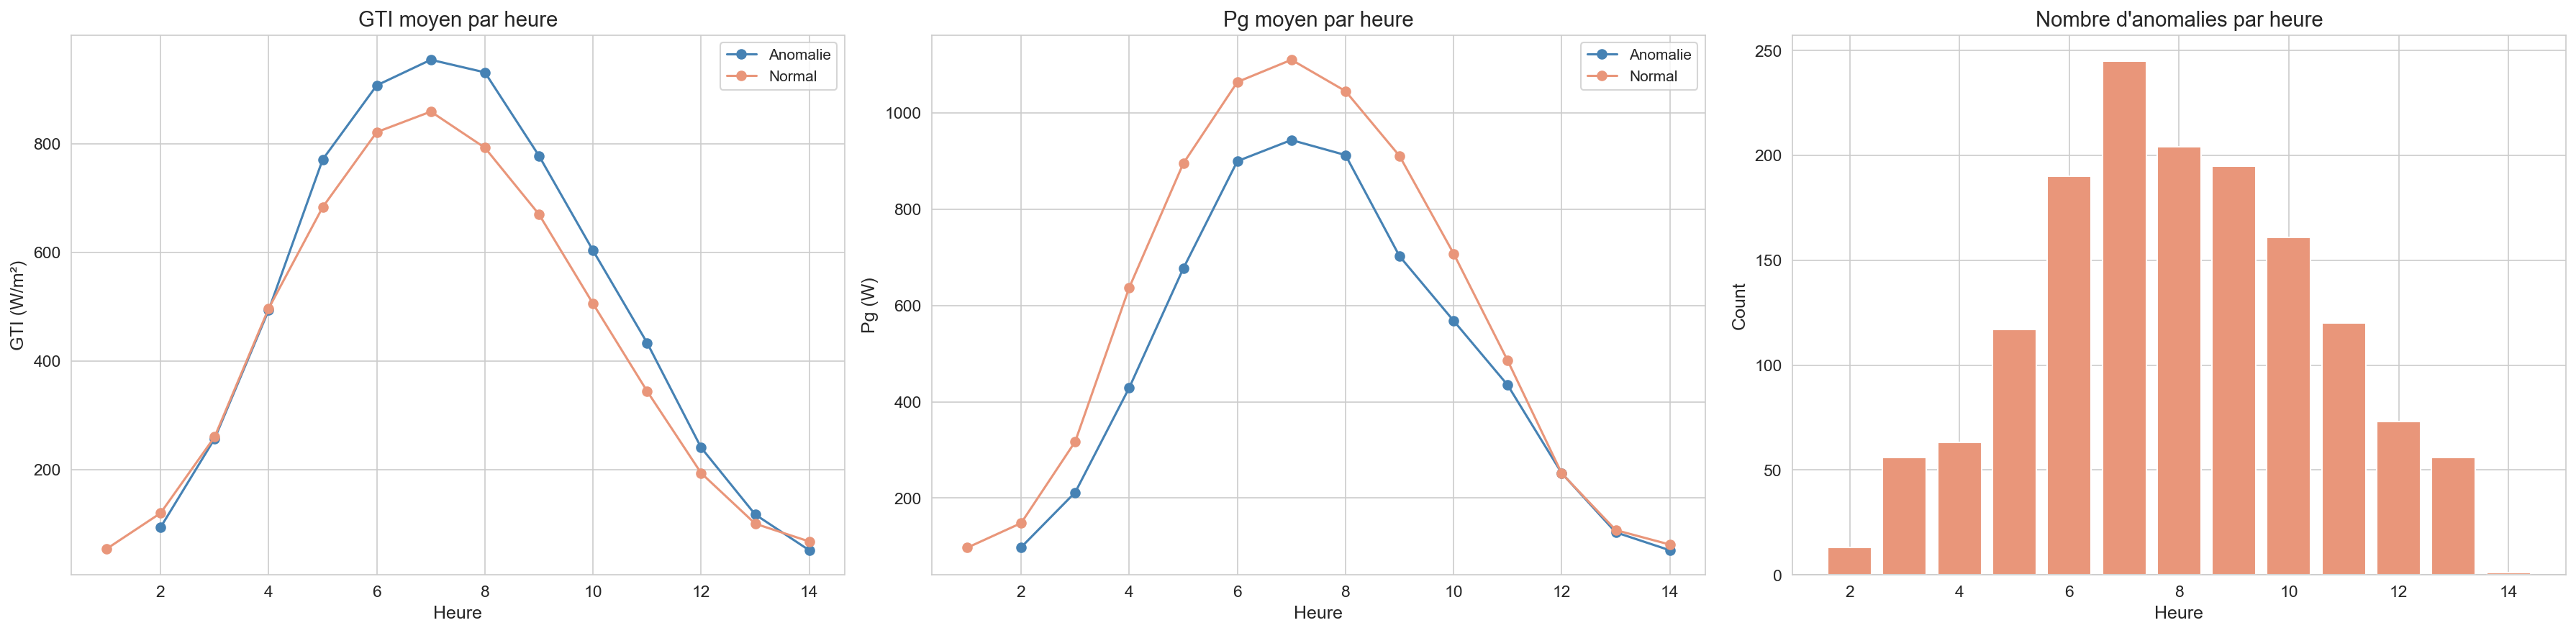

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(24, 6))

# GTI moyen par heure
hourly_gti = df.groupby(["hour", "fault_binary"])["GTI"].mean().unstack()
hourly_gti.plot(color=PALETTE_BINARY, marker="o", ax=axes[0])
axes[0].set_title("GTI moyen par heure")
axes[0].set_xlabel("Heure")
axes[0].set_ylabel("GTI (W/m²)")
axes[0].legend(title="")

# Pg moyen par heure
hourly_pg = df.groupby(["hour", "fault_binary"])["Pg"].mean().unstack()
hourly_pg.plot(color=PALETTE_BINARY, marker="o", ax=axes[1])
axes[1].set_title("Pg moyen par heure")
axes[1].set_xlabel("Heure")
axes[1].set_ylabel("Pg (W)")
axes[1].legend(title="")

# Nombre d'anomalies par heure
hourly_faults = df[df["Fault"] != 0].groupby("hour").size()
axes[2].bar(hourly_faults.index, hourly_faults.values, color="#E9967A", edgecolor="w")
axes[2].set_title("Nombre d'anomalies par heure")
axes[2].set_xlabel("Heure")
axes[2].set_ylabel("Count")

plt.tight_layout()
save_fig("eda_12_profil_journalier")
plt.show()

 ### 5.3 Séries temporelles — Zoom sur une semaine avec pannes

  ✓ Sauvegardé : notebooks/figures/eda_13_serie_temporelle_semaine.png


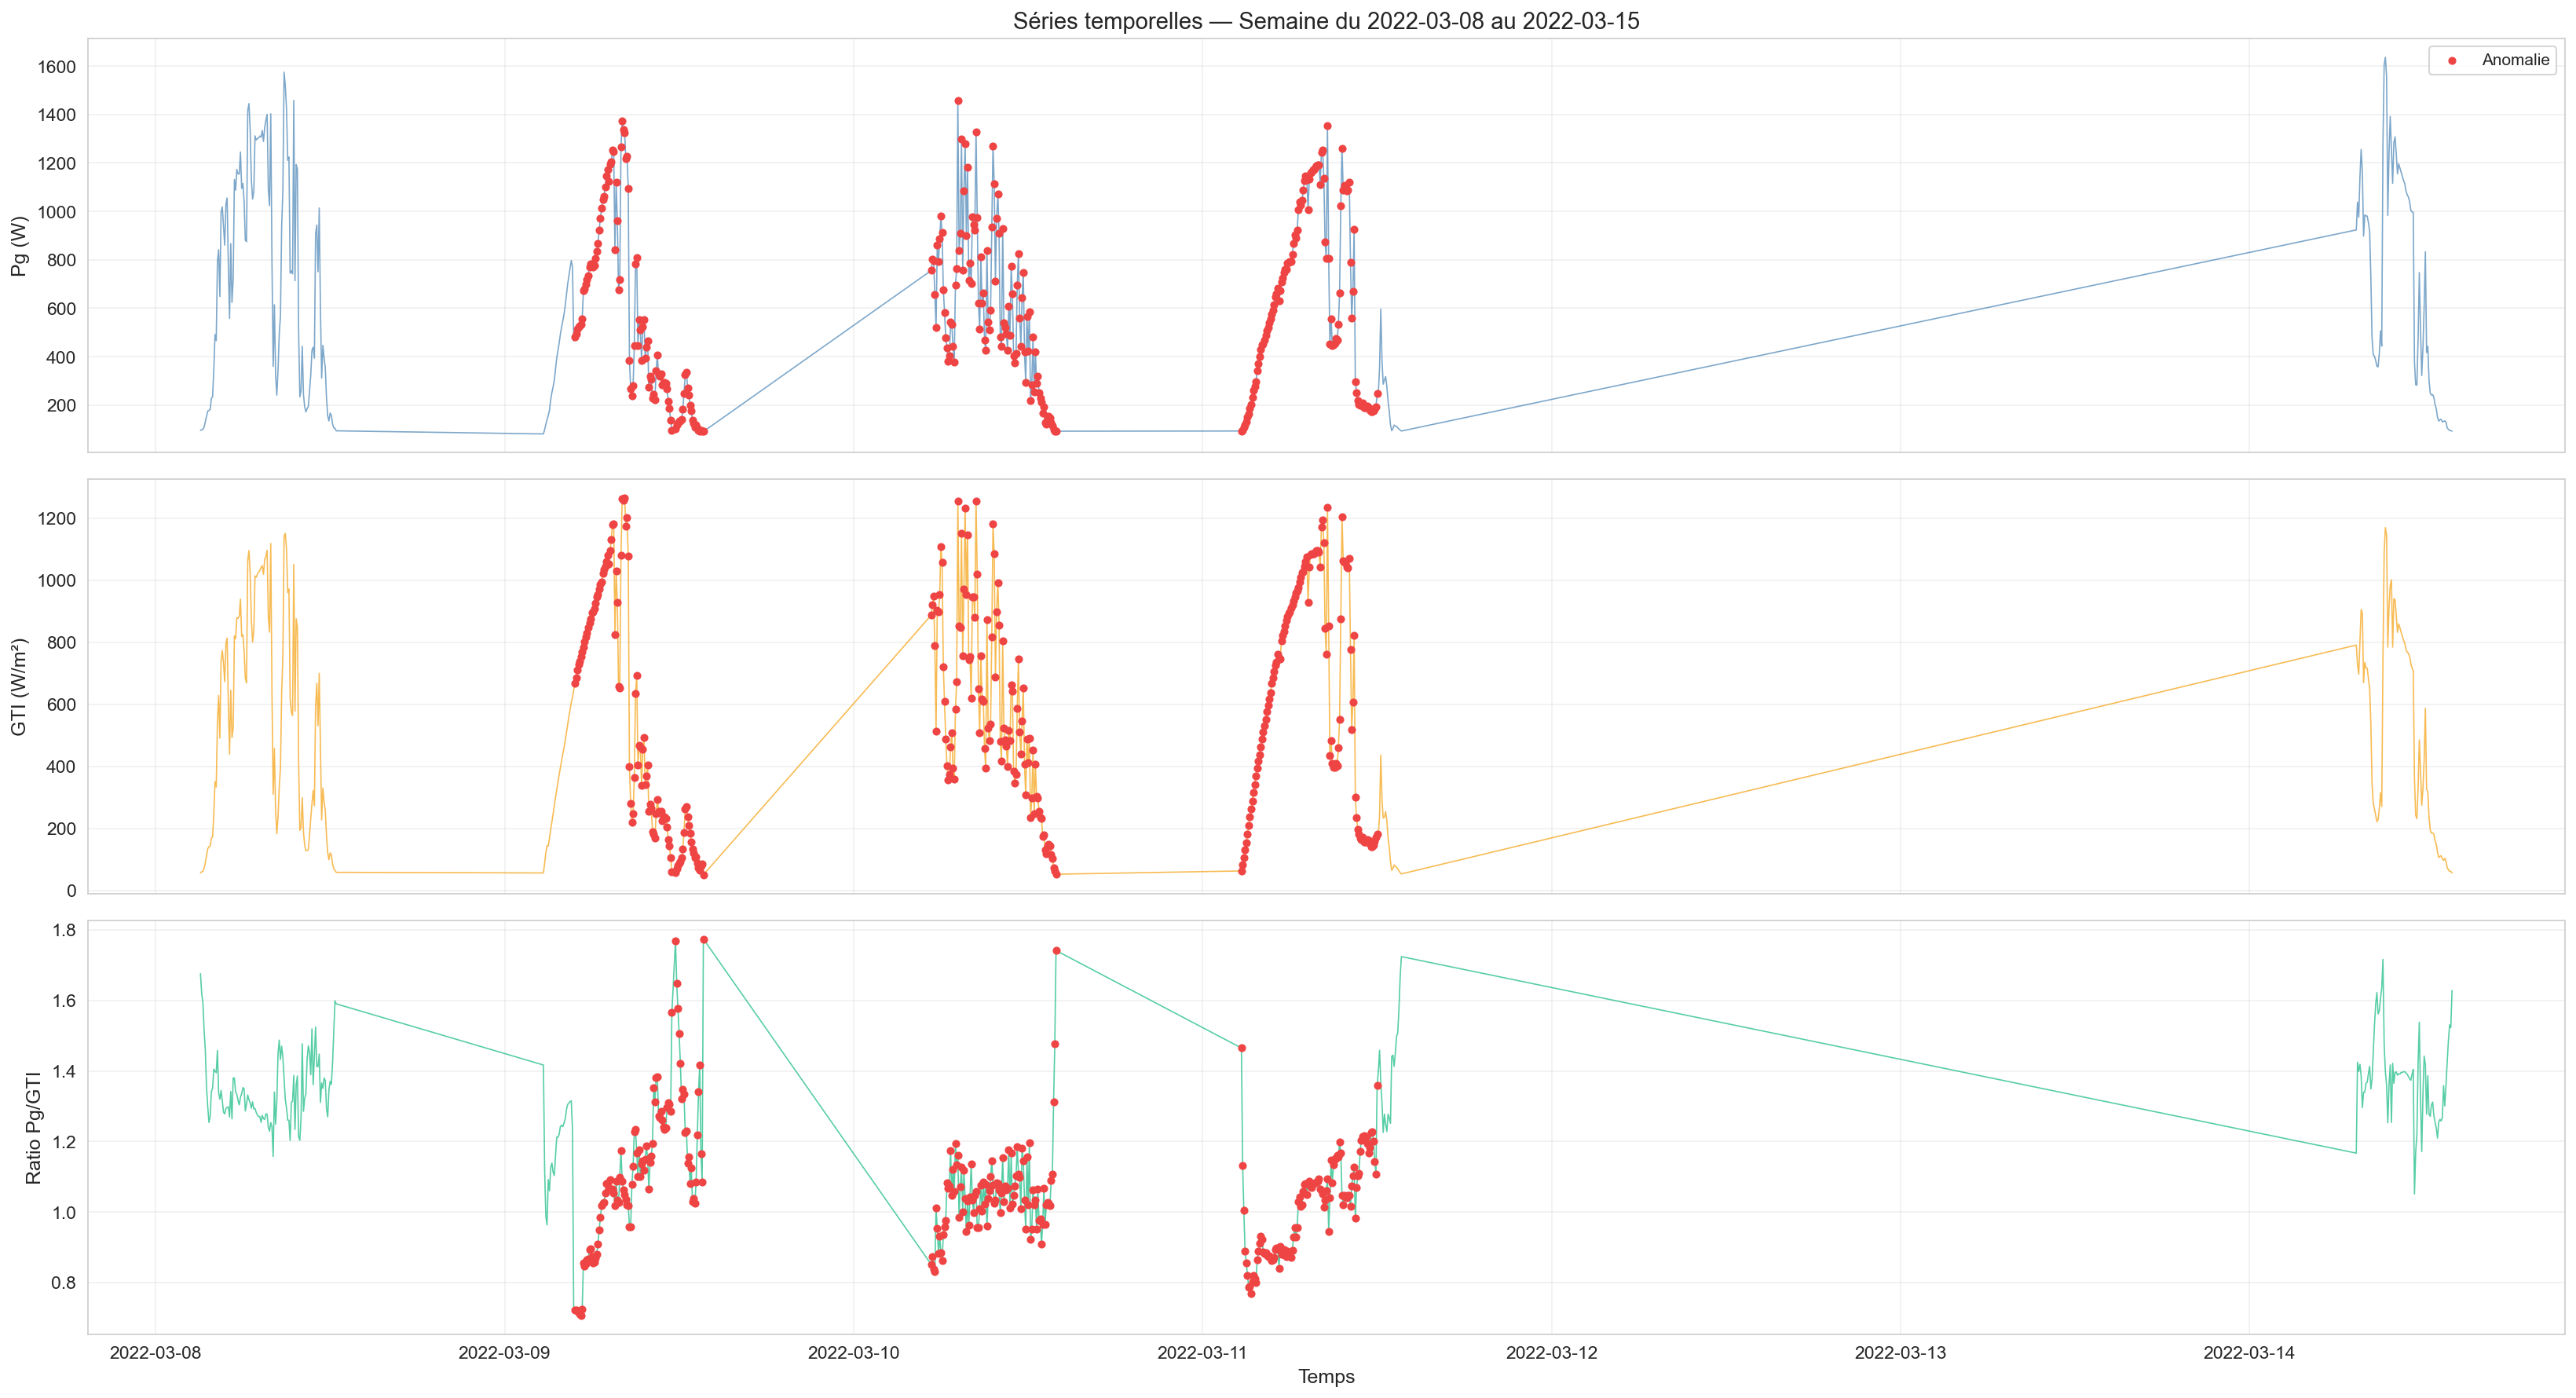

In [19]:
# Trouver une semaine avec des anomalies
fault_days = df[df["Fault"] != 0].index.normalize().unique()
if len(fault_days) > 0:
    target_day = fault_days[len(fault_days) // 2]  # milieu des jours de panne
    start = target_day - pd.Timedelta(days=3)
    end = target_day + pd.Timedelta(days=4)
    week = df.loc[start:end]

    fig, axes = plt.subplots(3, 1, figsize=(22, 12), sharex=True)

    # Pg
    axes[0].plot(week.index, week["Pg"], color="#4682B4", alpha=0.7, linewidth=0.8)
    fault_mask = week["Fault"] != 0
    axes[0].scatter(week.index[fault_mask], week["Pg"][fault_mask],
                    c="#EF4444", s=15, zorder=5, label="Anomalie")
    axes[0].set_ylabel("Pg (W)")
    axes[0].set_title(f"Séries temporelles — Semaine du {start.date()} au {end.date()}")
    axes[0].legend()

    # GTI
    axes[1].plot(week.index, week["GTI"], color="#F59E0B", alpha=0.7, linewidth=0.8)
    axes[1].scatter(week.index[fault_mask], week["GTI"][fault_mask],
                    c="#EF4444", s=15, zorder=5)
    axes[1].set_ylabel("GTI (W/m²)")

    # Ratio
    axes[2].plot(week.index, week["ratio_pg_gti"], color="#10B981", alpha=0.7, linewidth=0.8)
    axes[2].scatter(week.index[fault_mask], week["ratio_pg_gti"][fault_mask],
                    c="#EF4444", s=15, zorder=5)
    axes[2].set_ylabel("Ratio Pg/GTI")
    axes[2].set_xlabel("Temps")

    for ax in axes:
        ax.grid(alpha=0.3)

    plt.tight_layout()
    save_fig("eda_13_serie_temporelle_semaine")
    plt.show()

# ============================================================================

 ---
 ## 6. Analyse croisée — Feature engineering
 ---

 ### 6.1 Interaction des features créées

  ✓ Sauvegardé : notebooks/figures/eda_14_features_croisees.png


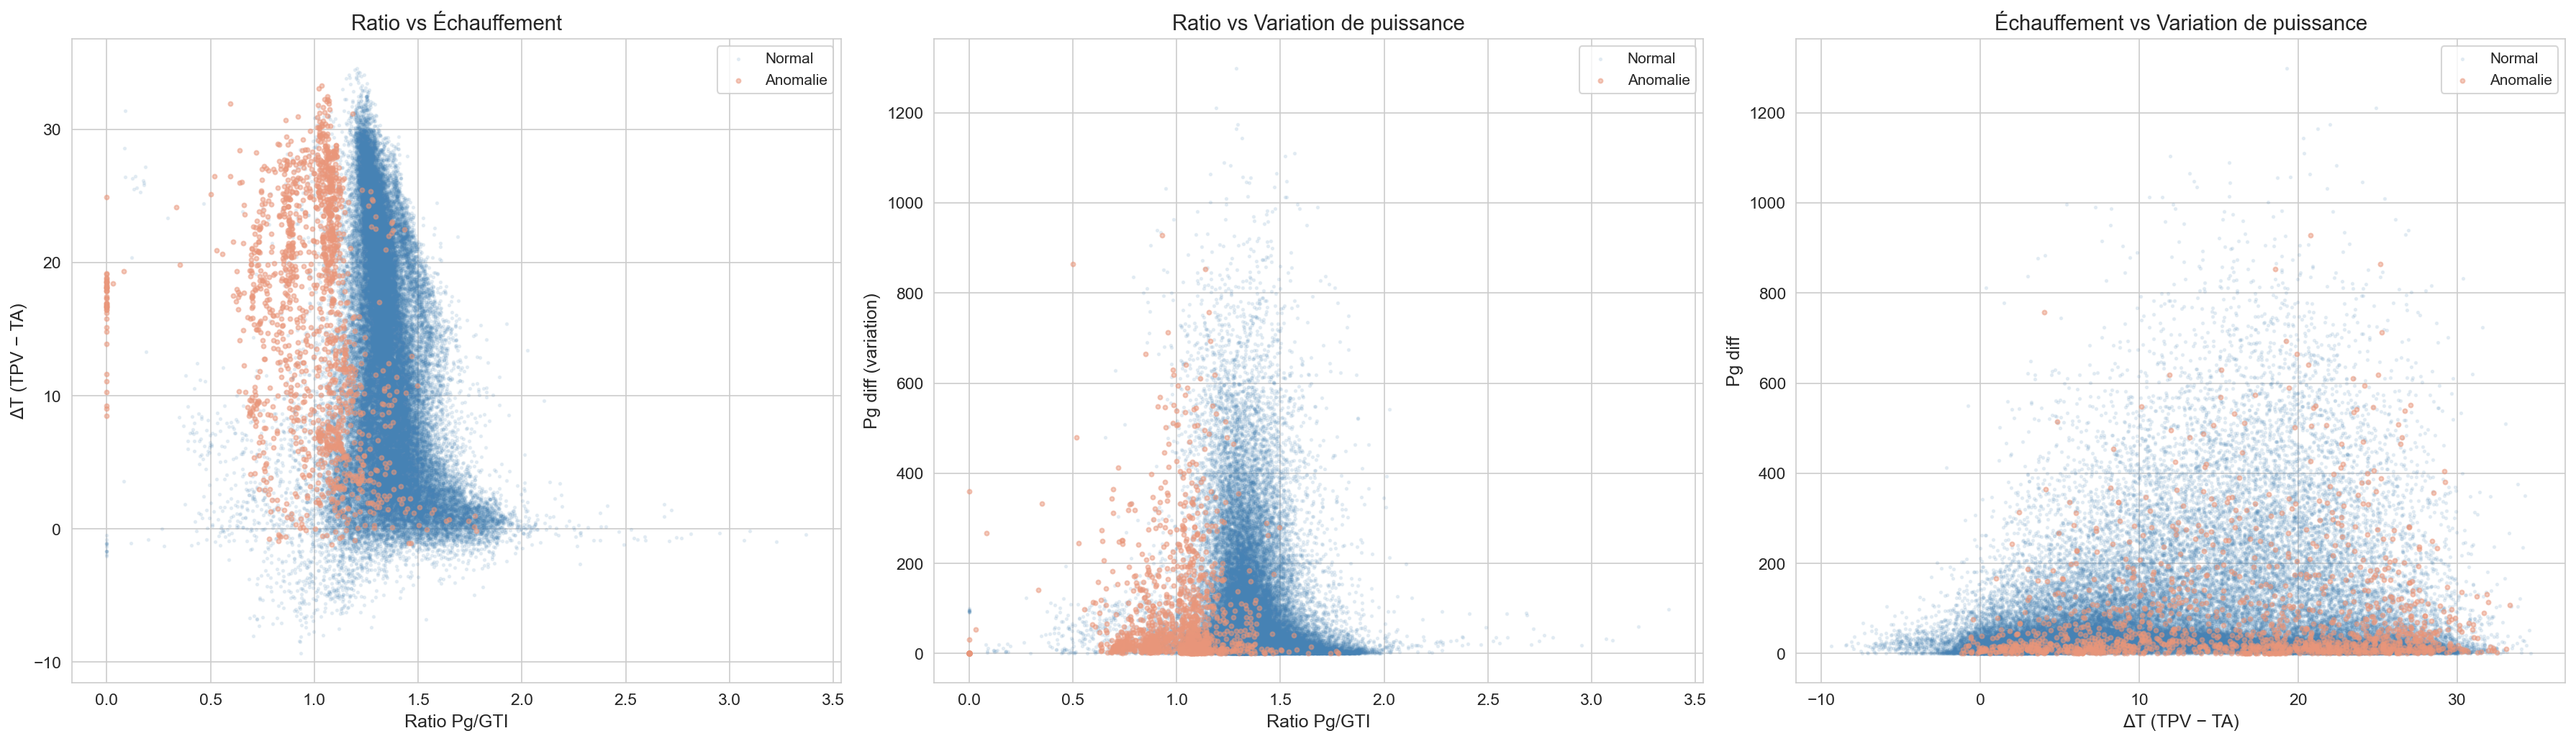

In [20]:
eng_features = ["ratio_pg_gti", "delta_tpv_ta", "pg_diff"]

fig, axes = plt.subplots(1, 3, figsize=(24, 7))

# ratio vs delta_tpv_ta
axes[0].scatter(df.loc[df["Fault"] == 0, "ratio_pg_gti"],
                df.loc[df["Fault"] == 0, "delta_tpv_ta"],
                c=COLORS_FAULT[0], alpha=0.1, s=3, label="Normal")
axes[0].scatter(df.loc[df["Fault"] != 0, "ratio_pg_gti"],
                df.loc[df["Fault"] != 0, "delta_tpv_ta"],
                c="#E9967A", alpha=0.5, s=8, label="Anomalie")
axes[0].set_xlabel("Ratio Pg/GTI")
axes[0].set_ylabel("ΔT (TPV − TA)")
axes[0].set_title("Ratio vs Échauffement")
axes[0].legend()

# ratio vs pg_diff
axes[1].scatter(df.loc[df["Fault"] == 0, "ratio_pg_gti"],
                df.loc[df["Fault"] == 0, "pg_diff"],
                c=COLORS_FAULT[0], alpha=0.1, s=3, label="Normal")
axes[1].scatter(df.loc[df["Fault"] != 0, "ratio_pg_gti"],
                df.loc[df["Fault"] != 0, "pg_diff"],
                c="#E9967A", alpha=0.5, s=8, label="Anomalie")
axes[1].set_xlabel("Ratio Pg/GTI")
axes[1].set_ylabel("Pg diff (variation)")
axes[1].set_title("Ratio vs Variation de puissance")
axes[1].legend()

# delta_tpv_ta vs pg_diff
axes[2].scatter(df.loc[df["Fault"] == 0, "delta_tpv_ta"],
                df.loc[df["Fault"] == 0, "pg_diff"],
                c=COLORS_FAULT[0], alpha=0.1, s=3, label="Normal")
axes[2].scatter(df.loc[df["Fault"] != 0, "delta_tpv_ta"],
                df.loc[df["Fault"] != 0, "pg_diff"],
                c="#E9967A", alpha=0.5, s=8, label="Anomalie")
axes[2].set_xlabel("ΔT (TPV − TA)")
axes[2].set_ylabel("Pg diff")
axes[2].set_title("Échauffement vs Variation de puissance")
axes[2].legend()

plt.tight_layout()
save_fig("eda_14_features_croisees")
plt.show()

 ### 6.2 Heatmap — Médiane des variables par type de panne

  ✓ Sauvegardé : notebooks/figures/eda_15_heatmap_ratio_mediane.png


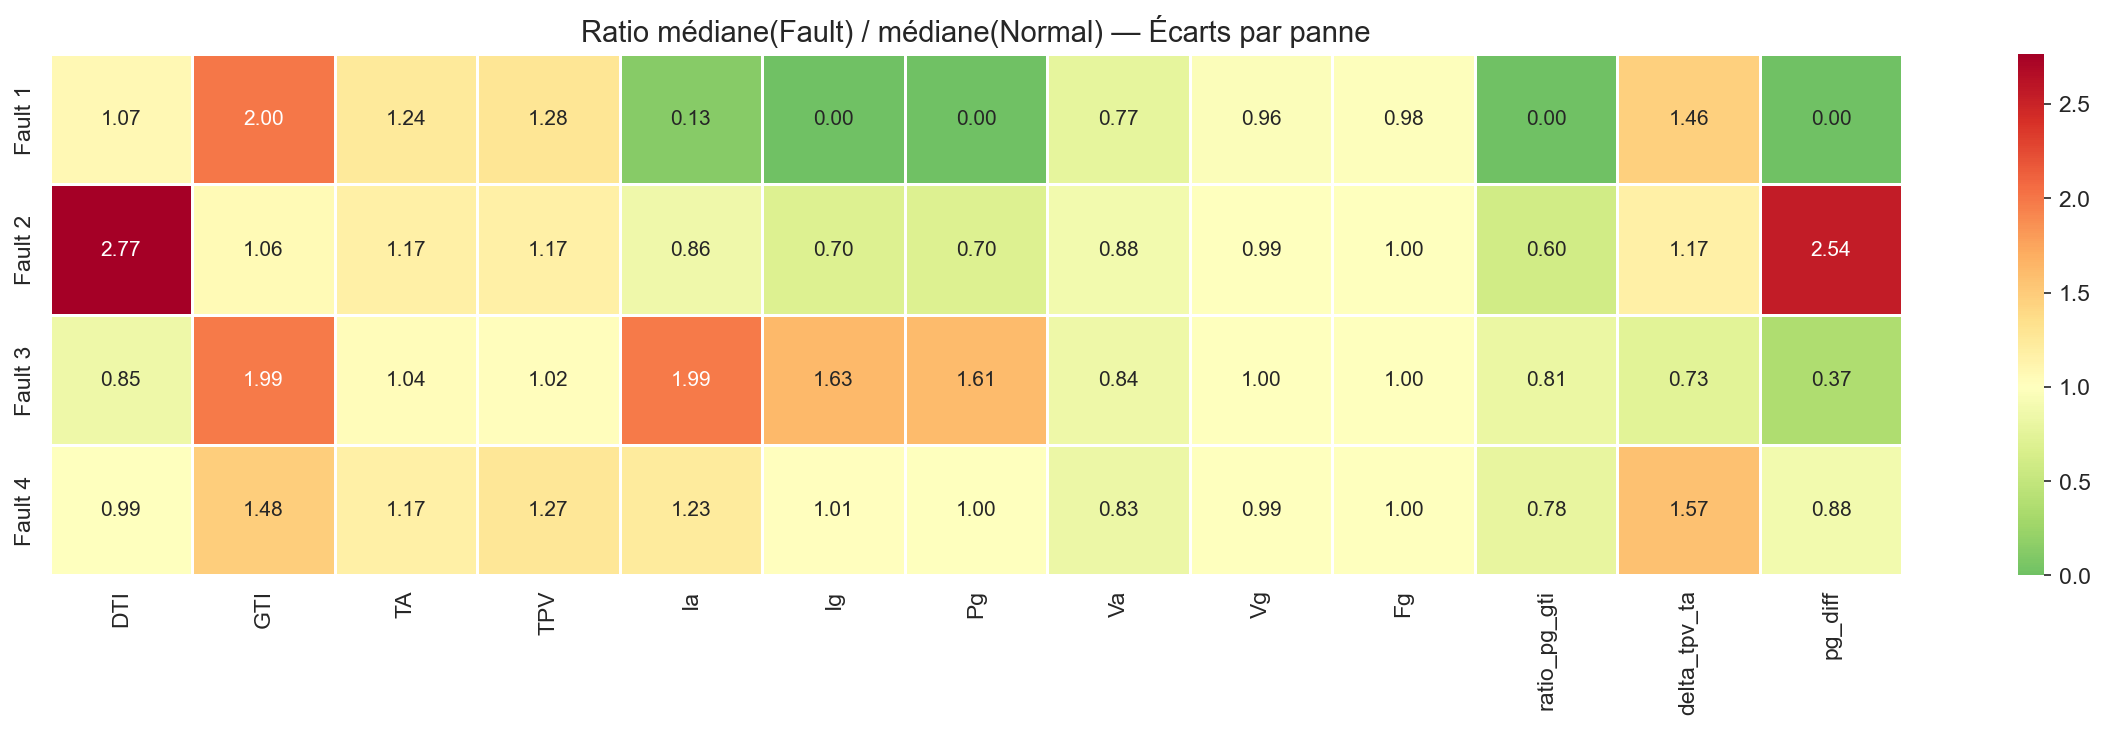

In [21]:
median_by_fault = df.groupby("fault_label")[features + eng_features].median()
median_by_fault = median_by_fault.reindex(
    [f for f in ["Normal", "Fault 1", "Fault 2", "Fault 3", "Fault 4", "Fault 5"]
     if f in median_by_fault.index]
)

# Normaliser par la ligne Normal pour voir les écarts relatifs
if "Normal" in median_by_fault.index:
    ratio_to_normal = median_by_fault.div(median_by_fault.loc["Normal"]).drop("Normal")

    fig, ax = plt.subplots(figsize=(16, 5))
    sns.heatmap(ratio_to_normal, annot=True, fmt=".2f", cmap="RdYlGn_r",
                center=1.0, linewidths=0.5, ax=ax,
                annot_kws={"size": 10})
    ax.set_title("Ratio médiane(Fault) / médiane(Normal) — Écarts par panne", fontsize=14)
    ax.set_ylabel("")
    plt.tight_layout()
    save_fig("eda_15_heatmap_ratio_mediane")
    plt.show()

# ============================================================================

 ---
 ## 7. Cumulative — Probabilité d'anomalie selon les seuils
 ---

 ### 7.1 Distribution cumulative du ratio Pg/GTI
 Inspiré de l'analyse cumulative de la durée dans le projet bancaire.

C:\Users\PC\AppData\Local\Temp\ipykernel_17056\294274969.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(data=df, x="fault_binary", y="ratio_pg_gti",


  ✓ Sauvegardé : notebooks/figures/eda_16_cumulative_ratio.png


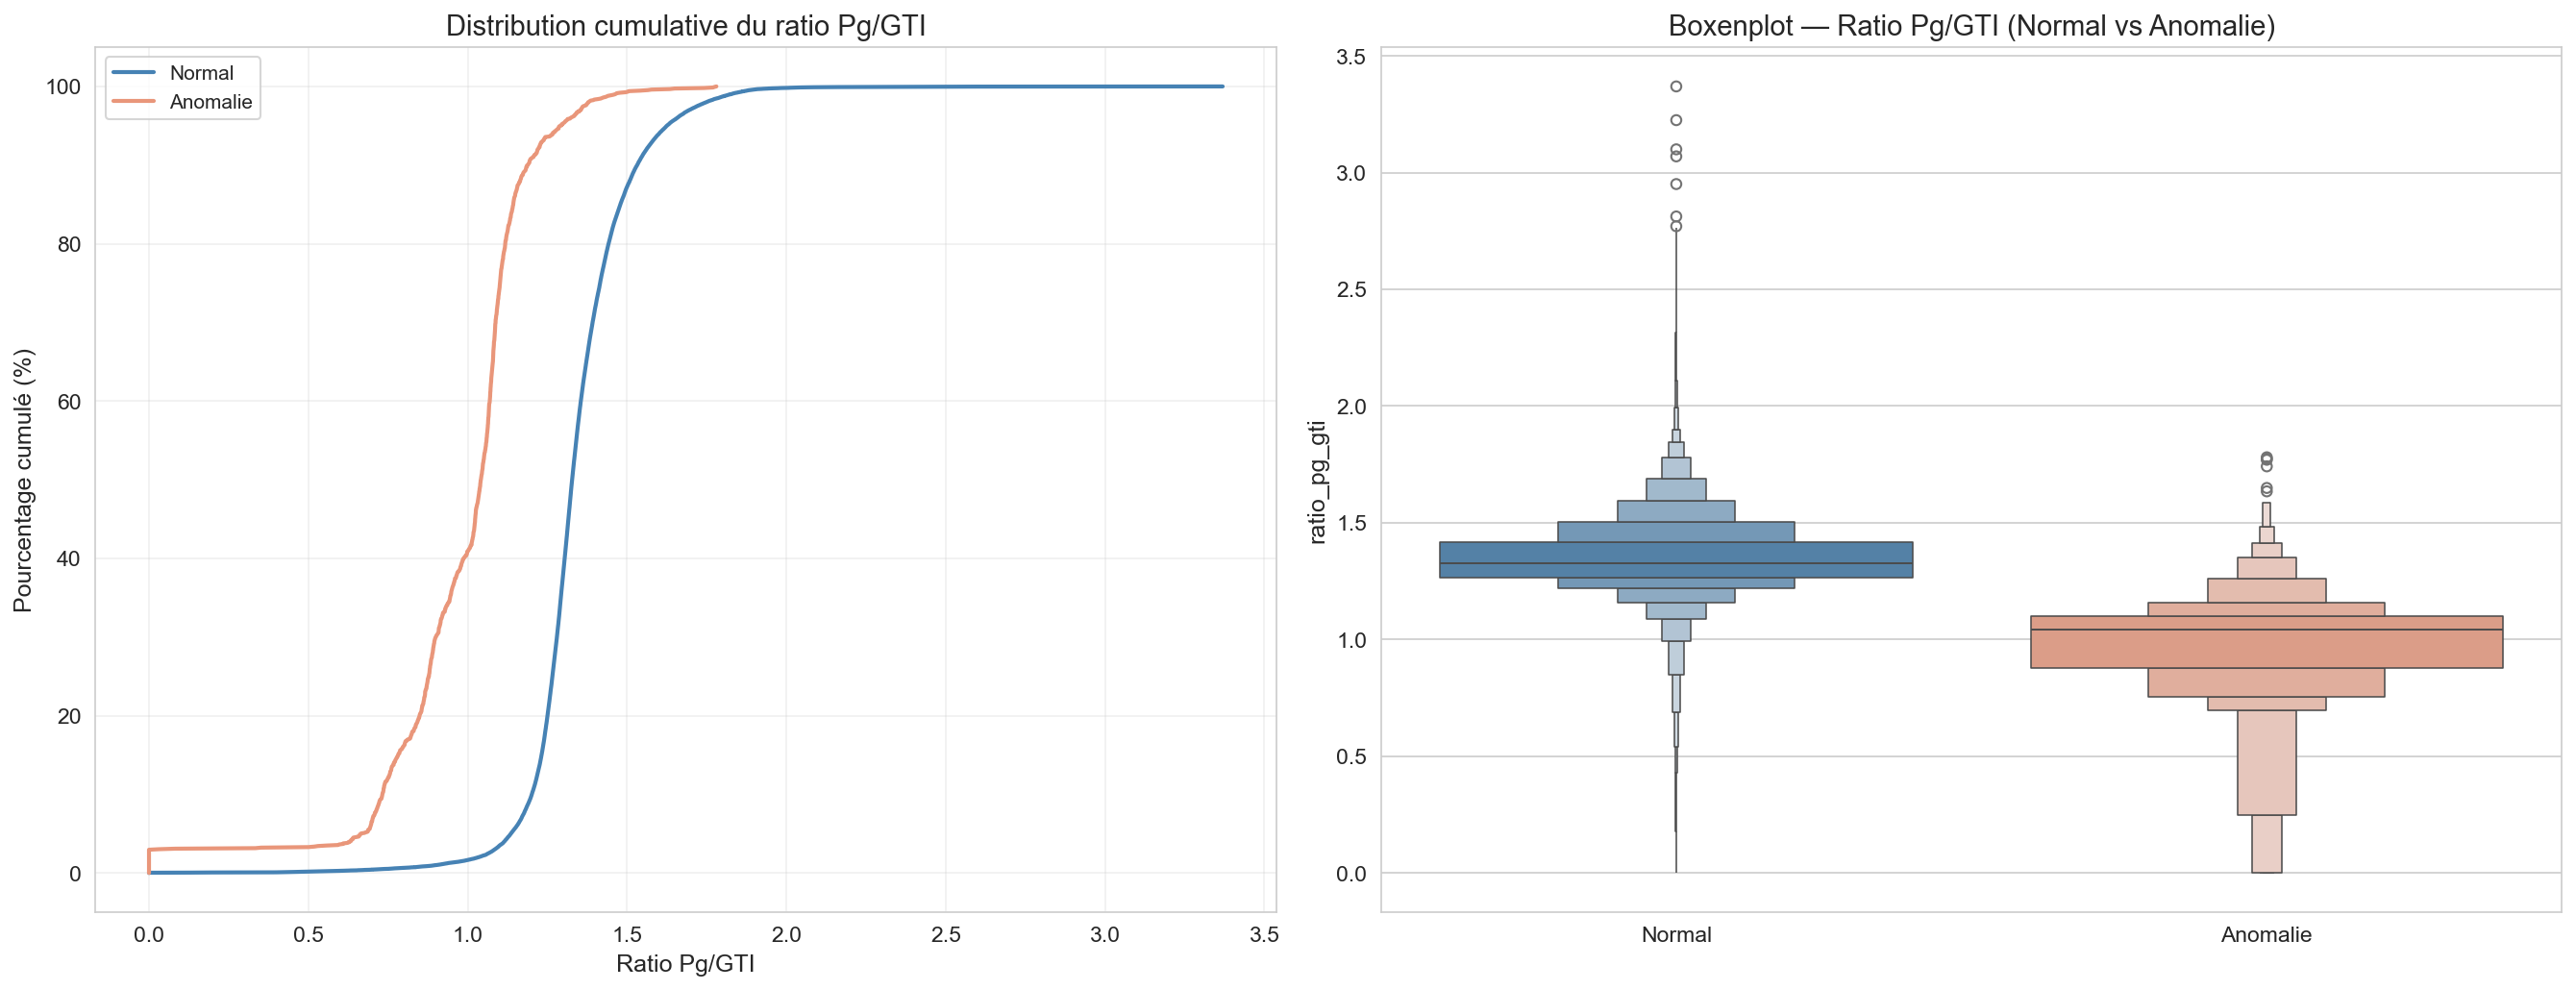

In [22]:
normal_ratio = df.loc[df["Fault"] == 0, "ratio_pg_gti"].dropna().sort_values()
anomaly_ratio = df.loc[df["Fault"] != 0, "ratio_pg_gti"].dropna().sort_values()

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# CDF
axes[0].plot(normal_ratio.values,
             np.linspace(0, 100, len(normal_ratio)),
             color=COLORS_FAULT[0], linewidth=2, label="Normal")
axes[0].plot(anomaly_ratio.values,
             np.linspace(0, 100, len(anomaly_ratio)),
             color="#E9967A", linewidth=2, label="Anomalie")
axes[0].set_xlabel("Ratio Pg/GTI")
axes[0].set_ylabel("Pourcentage cumulé (%)")
axes[0].set_title("Distribution cumulative du ratio Pg/GTI")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Distribution comparative
sns.boxenplot(data=df, x="fault_binary", y="ratio_pg_gti",
              palette=PALETTE_BINARY, ax=axes[1])
axes[1].set_title("Boxenplot — Ratio Pg/GTI (Normal vs Anomalie)")
axes[1].set_xlabel("")

plt.tight_layout()
save_fig("eda_16_cumulative_ratio")
plt.show()

# ============================================================================

 ---
 ## Résumé des observations
 ---
 **Ce qu'on a appris :**

 1. **GTI ↔ Pg** : relation linéaire forte (r ≈ 0.98), les anomalies
    se situent systématiquement sous la droite (production dégradée)
 2. **Ratio Pg/GTI** : indicateur clé — chute nette en cas de panne
 3. **Température** : ΔT (TPV−TA) varie selon le type de panne
 4. **Profil temporel** : certains mois concentrent plus d'anomalies
 5. **Types de pannes** : signatures différentes dans l'espace des features,
    certaines plus faciles à séparer que d'autres (cf. t-SNE du notebook 03)

 **Prochaine étape** : Phase 2 — Random Forest (baseline supervisé)